In [1]:
import numpy as np
import netCDF4 as nc4
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import os
import pandas as pd
import geopandas as gpd
from cmcrameri import cm
from tqdm.notebook import tqdm, trange
import time    # to be used in loop iterations
import cartopy.crs as ccrs
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
from scipy.interpolate import griddata
import glob
from PIL import Image


In [2]:
inv_run = 'MDL_25k_pm250_reg_5_7500m_mag_raw/'

In [3]:
grav_mag_pd = pd.read_csv(
    "DATA/Grav_mag_input_jif3d.txt",
    skiprows=1,
    names=["x_ps", "y_ps", "Surface", "Bouguer_HP", "Magnetics_10km_LP30", "Lon" , "Lat"],
)

Boundaries = pd.read_csv(
    "DATA/Boundaries_jif3d.txt",
    skiprows=1,
    names=["x_ps", "y_ps", "BED_filt", "moho_calc_250", "Lon", "Lat"],
)

# Coastline = gpd.read_file('DATA/ADD_Coastline.gpkg')

In [4]:
export_fig_path = inv_run + 'Output/Figure/'

# Create path if it does not exists
if not os.path.exists(export_fig_path):
    os.makedirs(export_fig_path)
    
unit_dens = 'kg/m$^3$'
unit_sus = 'SI'

In [5]:
# Define the custom Transverse Mercator projection
custom_tm = ccrs.TransverseMercator(
    central_longitude=0,        # lon_0
    central_latitude=-90,       # lat_0
    scale_factor=0.994,         # k
    false_easting=2000000,      # x_0
    false_northing=2000000      # y_0
)

In [6]:
###### Grav data ######
nc = nc4.Dataset(inv_run+'VI_inversion/gravdata.nc')  # grav data set
X_input_grav = nc.variables['MeasPosX'][:] # x coordinates
Y_input_grav = nc.variables['MeasPosY'][:] # y coordinates 
val_input_grav = nc.variables['Scalar_gravity'][:] *1e5  # gravity data converted from SI units to mGal
unit_grav = 'mGal'

##### Mag data ######
nc1 = nc4.Dataset(inv_run+'VI_inversion/magdata.nc')  # mag data set
X_input_mag = nc1.variables['MeasPosX'][:] # x coordinates
Y_input_mag = nc1.variables['MeasPosY'][:] # y coordinates
val_input_mag = nc1.variables['T'][:]   # magnetic data
unit_mag = 'nT'

##### Inverted Results ######
#### Grav ####
G = nc4.Dataset(inv_run+'VI_inversion/result.inv_sgd.nc')   # syn grav data set
X_syn_grav = G.variables['MeasPosX'][:] # x coordinates
Y_syn_grav = G.variables['MeasPosY'][:] # y coordinates 
val_syn_grav = G.variables['Scalar_gravity'][:]*1e5  # syn gravity data

diff_grav = val_input_grav - val_syn_grav  # difference observed and syn gravity data
diff_grav_pd = pd.DataFrame(diff_grav, columns = ['diff_grav'])
mxn_d=max(abs(max(diff_grav)),abs(min(diff_grav)))

#### Mag ####
G1 = nc4.Dataset(inv_run+'VI_inversion/result.inv_mag.nc')   # syn mag data set
X_syn_mag = G1.variables['MeasPosX'][:] # x coordinates
Y_syn_mag = G1.variables['MeasPosY'][:] # y coordinates
val_syn_mag = G1.variables['T'][:]       # syn magnetic data


diff_mag = val_input_mag - val_syn_mag   # difference observed and syn magnetic data
diff_mag_pd = pd.DataFrame(diff_mag, columns = ['diff_mag'])
mxn_mag=max(abs(max(diff_mag)),abs(min(diff_mag)))


nc.close()
nc1.close()
G.close()
G1.close()

max grav error : 39.4 mGal
min grav error : -38.9 mGal
mean grav error : 0.0 mGal
std grav error : 4.5 mGal 

max mag error : 270.2 nT
min mag error : -41.6 nT
mean mag error : -0.1 nT
std mag error : 6.4 nT 



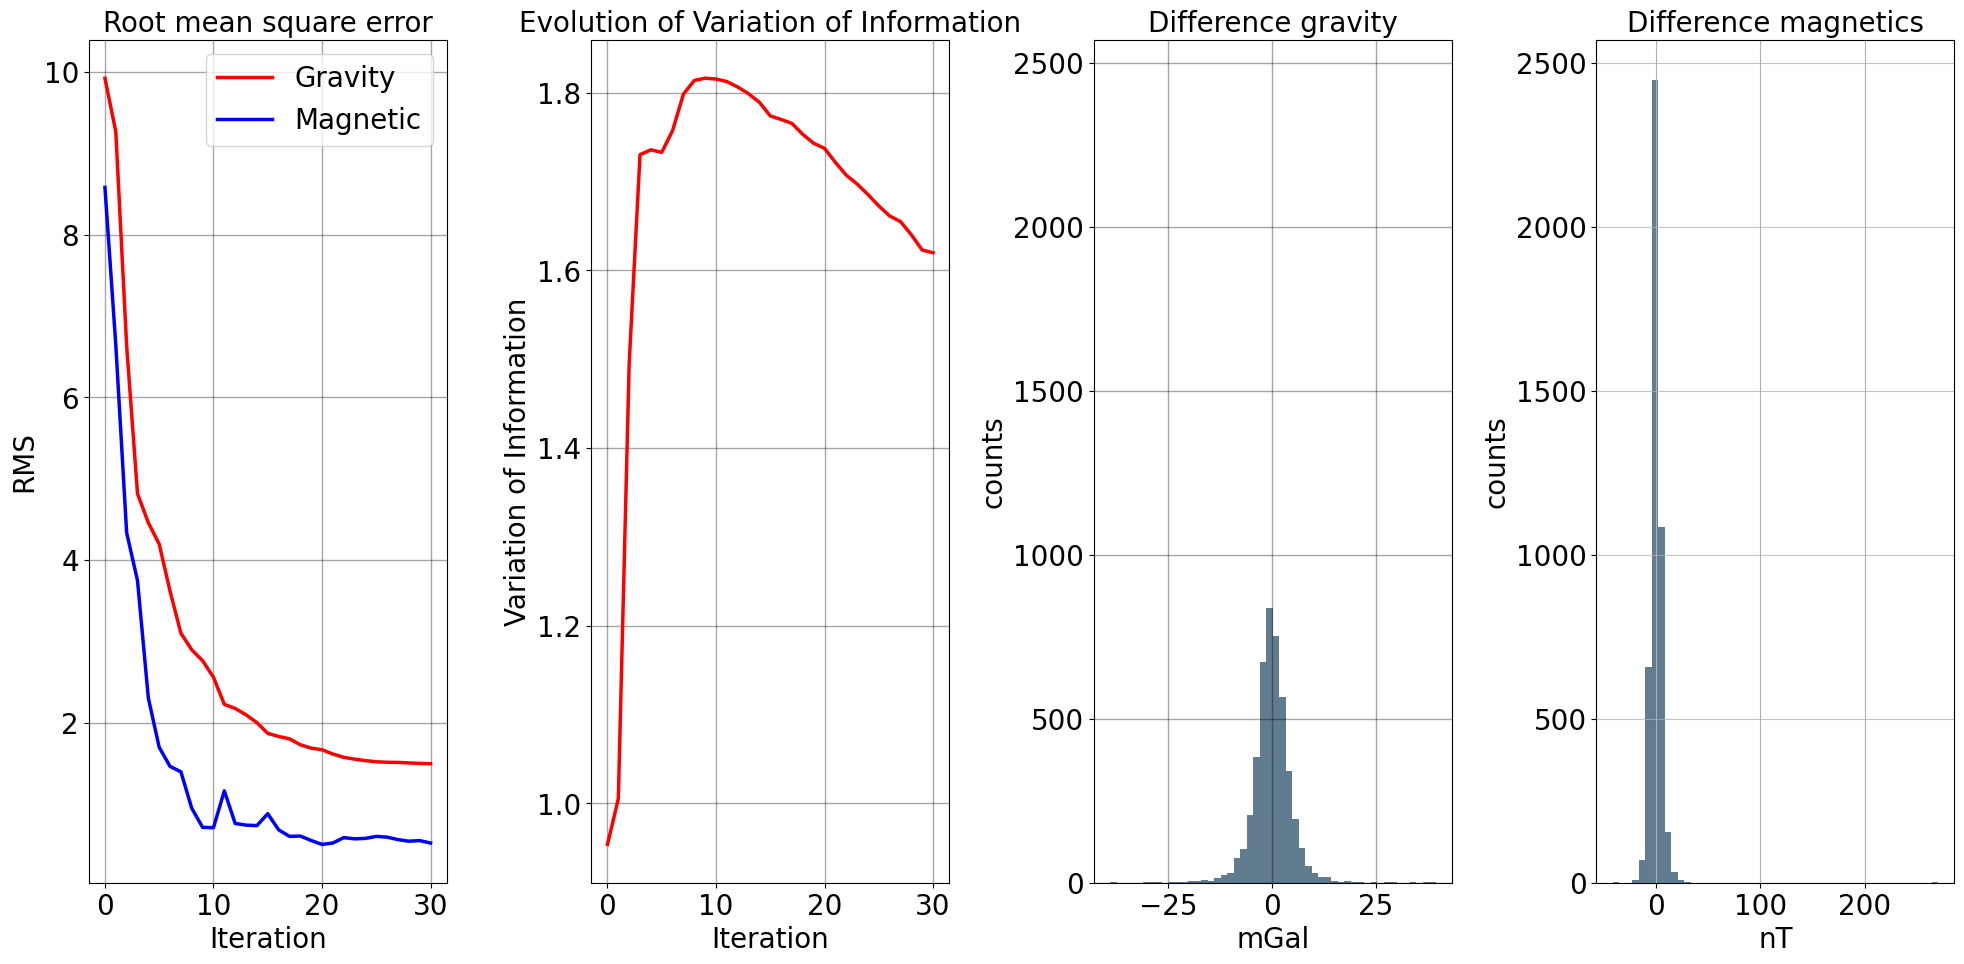

In [7]:
# load missift and rms data 


run1_misfit = np.genfromtxt(inv_run+'VI_inversion/misfit.out')
run1_rms = np.genfromtxt(inv_run+'VI_inversion/rms.out')

rms = run1_rms
misfit = run1_misfit


figure1, axs = plt.subplots(1, 4, figsize=(20,10),facecolor='white')

axs[0].plot(rms[:,1] , '-r' , linewidth=2.5 , label='Gravity')
axs[0].plot(rms[:,2] , '-b' , linewidth=2.5 , label='Magnetic')
axs[0].legend(loc='upper right' , prop={'size': 20})
axs[0].set_title("Root mean square error" , fontsize=20)
axs[0].set_xlabel('RMS', fontsize=20)
axs[0].grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')
axs[0].set_xlabel('Iteration' , fontsize=20)
axs[0].set_ylabel('RMS' , fontsize=20)
axs[0].tick_params(axis="x", labelsize=20) 
axs[0].tick_params(axis="y", labelsize=20) 

axs[1].plot(misfit[:,4] , '-r' , linewidth=2.5)
axs[1].set_title('Evolution of Variation of Information' , fontsize=20)
axs[1].set_xlabel('Iteration', fontsize=20)
axs[1].set_ylabel('Variation of Information', fontsize=20)
# axs[2].sharey(axs[1])
axs[1].grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')
axs[1].tick_params(axis="x", labelsize=20) 
axs[1].tick_params(axis="y", labelsize=20) 


diff_grav_pd.diff_grav.plot.hist(grid=True, bins=50 , ax=axs[2] ,  color='#607c8e')
axs[2].set_title('Difference gravity', fontsize=20)
axs[2].set_xlabel('mGal', fontsize=20)
axs[2].set_ylabel('counts', fontsize=20)
axs[2].grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')
axs[2].tick_params(axis="x", labelsize=20) 
axs[2].tick_params(axis="y", labelsize=20) 

diff_mag_pd.diff_mag.plot.hist(grid=True, bins=50 , ax=axs[3] ,  color='#607c8e')
axs[3].set_title('Difference magnetics' , fontsize=20)
axs[3].set_xlabel('nT', fontsize=20)
axs[3].set_ylabel('counts', fontsize=20)

axs[3].grid(axis='y', alpha=0.75)
axs[3].tick_params(axis="x", labelsize=20) 
axs[3].tick_params(axis="y", labelsize=20) 

axs[2].sharey(axs[3])

figure1.tight_layout(pad=2)

plt.savefig(export_fig_path + 'inversion_stats.png',facecolor=figure1.get_facecolor(), transparent=True)



print("max grav error :", '{0:.1f}'.format(np.max(diff_grav)) , "mGal")
print("min grav error :", '{0:.1f}'.format(np.min(diff_grav)) , "mGal"),
print("mean grav error :", '{0:.1f}'.format(np.mean(diff_grav)) , "mGal")
print("std grav error :", '{0:.1f}'.format(np.std(diff_grav)) , "mGal \n")

print("max mag error :", '{0:.1f}'.format(np.max(diff_mag)) , "nT")
print("min mag error :", '{0:.1f}'.format(np.min(diff_mag)) , "nT"),
print("mean mag error :", '{0:.1f}'.format(np.mean(diff_mag)) , "nT")
print("std mag error :", '{0:.1f}'.format(np.std(diff_mag)) , "nT \n")



In [8]:
rms[:,1]

array([9.92096, 9.26336, 6.63291, 4.8156 , 4.45808, 4.195  , 3.61645,
       3.10067, 2.89654, 2.76209, 2.5591 , 2.22607, 2.17605, 2.09772,
       2.00169, 1.87019, 1.83153, 1.80262, 1.7303 , 1.68811, 1.66811,
       1.61557, 1.57529, 1.55274, 1.53453, 1.52068, 1.5144 , 1.51284,
       1.50624, 1.50048, 1.49701])

In [9]:
rms[:,2]

array([8.57869 , 6.64442 , 4.33582 , 3.74791 , 2.30309 , 1.6982  ,
       1.46365 , 1.39665 , 0.948688, 0.714917, 0.710437, 1.16365 ,
       0.762181, 0.742148, 0.735979, 0.882365, 0.684897, 0.604079,
       0.607678, 0.553237, 0.505002, 0.522478, 0.588374, 0.573533,
       0.57907 , 0.603569, 0.594015, 0.563949, 0.544489, 0.551898,
       0.521937])

In [10]:
#read in magnetic inversion model
mag_fh = Dataset(inv_run+"VI_inversion/result.mag.inv.nc")
X_sus = mag_fh.variables["Northing"][:]
Y_sus =mag_fh.variables["Easting"][:] 
Depth_sus =mag_fh.variables["Depth"][:]
X_sus_Origin =mag_fh.variables["Northing_Origin"][:] 
Y_sus_Origin =mag_fh.variables["Easting_Origin"][:] 
Depth_sus_Origin =mag_fh.variables["Depth_Origin"][:]
inv_sus = mag_fh.variables["Susceptibility"][:,:,:]
mag_fh.close()

#and the corresponding gravity model, do not need geometry as we know it is the same
grav_fh = Dataset(inv_run+"VI_inversion/result.grav.inv.nc")
inv_dens = grav_fh.variables["Density"][:,:,:]
grav_fh.close()

In [11]:
inv_sus.shape

(40, 94, 119)

In [12]:
xq , yq = np.meshgrid(X_sus , Y_sus)
Depth_inversion_km = np.round((Depth_sus/1000),1)

In [13]:
# line_x = (min(xq[0,:])  , max(xq[0,:]))
# line_y = (yq[74,0] , yq[74,0])
# line_y

In [14]:
# define polygon extend (here I use values for Queen Maud Land (QML) area)
x_ps_point_list = [-1.0e6, -1.0e6, 1.5e6, 1.5e6, -1.0e6]
y_ps_point_list = [1.0e6, 2.5e6, 2.5e6, 1.0e6, 1.0e6]

# create polygon and convert into a geopanda dataframe with a coordinate reference system (CRS) of WGS 84 / Antarctic Polar Stereographic
polygon_geom = Polygon(zip(x_ps_point_list, y_ps_point_list))
polygon_QML = gpd.GeoDataFrame(index=[0], crs="epsg:3031", geometry=[polygon_geom])

In [15]:
Coastline = gpd.read_file("../GeoMap/ADD_Coastline.gpkg", mask=polygon_QML)

faults_QML = gpd.read_file(
    "../GeoMap/ATA_SCAR_GeoMAP_Geology_v2022_08.gpkg",
    layer="ATA_GeoMAP_faults_v2022_08",
    mask=polygon_QML,
)

C:\Users\sungw935\.conda\envs\equ_layer\Lib\site-packages\geopandas\io\file.py:497: UserWarning: More than one layer found in 'ATA_SCAR_GeoMAP_Geology_v2022_08.gpkg': 'ATA_GeoMAP_faults_v2022_08' (default), 'ATA_GeoMAP_sources_v2022_08', 'ATA_GeoMAP_geological_units_v2022_08', 'ATA_GeoMAP_quality_v2022_08'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(path_or_bytes).get("crs")


In [16]:
m=15 #fontsize
cmap = cm.roma_r
cmap_rev = cm.roma_r
cmap_diff = cm.vik


In [17]:
X_input_grav.min()

-322951.483148084

In [18]:
Y_input_grav.min()

1565825.37326591

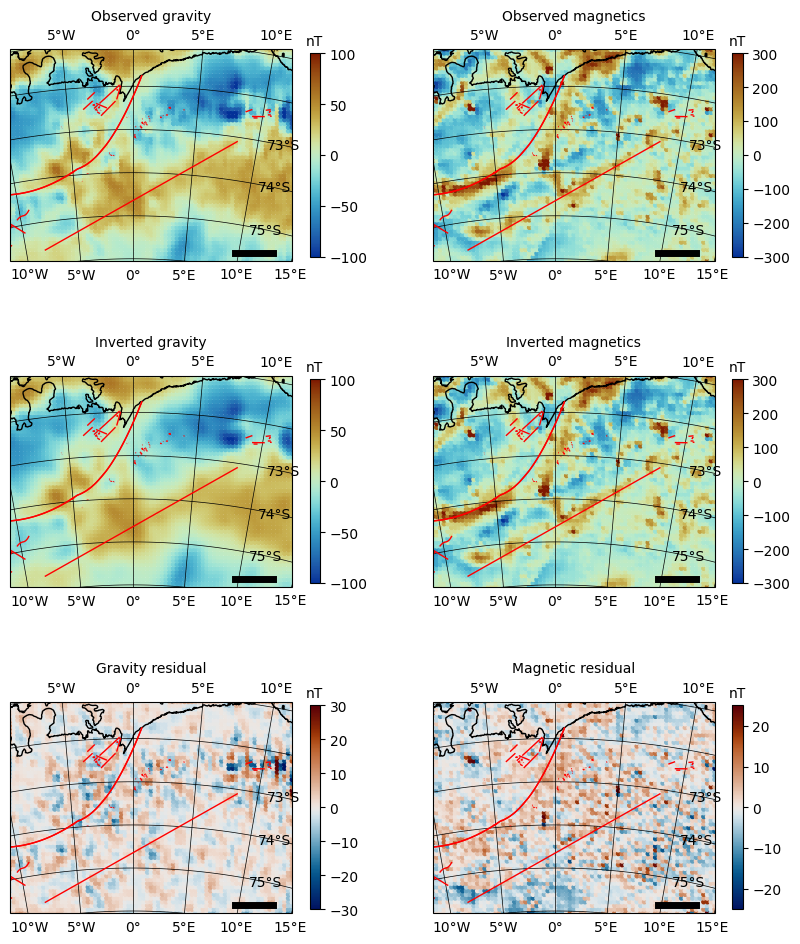

In [158]:
# create figure
figure1 = plt.figure(figsize=(10, 12), facecolor="white")

# grav data
ax1 = plt.subplot(3, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Observed gravity", fontsize=10)
im1 = plt.scatter(X_input_grav , Y_input_grav , 7, c=val_input_grav , cmap=cmap_rev, vmin =-100, vmax=100 )
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im1, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax1.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax1.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax1.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="red", linewidth=1)
ax1.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar

ax2 = plt.subplot(3, 2, 3, projection=ccrs.SouthPolarStereo())
plt.title("Inverted gravity", fontsize=10)
im2 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_syn_grav , cmap=cmap_rev, vmin =-100, vmax=100 )
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im2, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax2.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax2.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax2.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax2 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax2, color="red", linewidth=1)
ax2.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar


ax3 = plt.subplot(3, 2, 5, projection=ccrs.SouthPolarStereo())
plt.title("Gravity residual", fontsize=10)
im3 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_input_grav-val_syn_grav , cmap=cmap_diff, vmin=-30, vmax=30)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im3, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax3.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax3.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax3.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax3 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax3, color="red", linewidth=1)
ax3.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar

ax4 = plt.subplot(3, 2, 2, projection=ccrs.SouthPolarStereo())
plt.title("Observed magnetics", fontsize=10)
im4 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_input_mag , cmap=cmap_rev, vmin = -300, vmax = 300)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im4, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax4.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax4.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax4.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax4 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax4, color="red", linewidth=1)
ax4.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar


ax5 = plt.subplot(3, 2, 4, projection=ccrs.SouthPolarStereo())
plt.title("Inverted magnetics", fontsize=10)
im5 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_syn_mag , cmap=cmap_rev , vmin = -300, vmax = 300)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im5, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax5.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax5.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax5.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax5 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax5, color="red", linewidth=1)
ax5.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar


ax6 = plt.subplot(3, 2, 6, projection=ccrs.SouthPolarStereo())
plt.title("Magnetic residual", fontsize=10)
im6 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_input_mag-val_syn_mag , cmap=cmap_diff, vmin = -25, vmax = 25)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im6, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax6.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax6.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax6.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax6 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax6, color="red", linewidth=1)
ax6.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar


plt.savefig(inv_run+'Output/Figure/VI_inversion_maps_with_profil_location.png',facecolor=figure1.get_facecolor(), transparent=True)


In [20]:
x_study_area = [grav_mag_pd.x_ps.min(),  grav_mag_pd.x_ps.max(),  grav_mag_pd.x_ps.max(), grav_mag_pd.x_ps.min(), grav_mag_pd.x_ps.min()]
y_study_area = [grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max(), grav_mag_pd.y_ps.max(), grav_mag_pd.y_ps.min()]

In [21]:
grav_mag_pd.x_ps.min()

-322951.483148084

## Plot inverted density and susceptibility values

#### load sussceptibility and density values

In [22]:
#read in magnetic inversion model
mag_fh = Dataset(inv_run+"VI_inversion/result.mag.inv.nc")
X_sus = mag_fh.variables["Northing"][:] 
Y_sus =mag_fh.variables["Easting"][:] 
Depth_sus =mag_fh.variables["Depth"][:]
X_sus_Origin =mag_fh.variables["Northing_Origin"][:] 
Y_sus_Origin =mag_fh.variables["Easting_Origin"][:] 
Depth_sus_Origin =mag_fh.variables["Depth_Origin"][:]
inv_sus = mag_fh.variables["Susceptibility"][:,:,:]
mag_fh.close()

#and the corresponding gravity model, do not need geometry as we know it is the same
grav_fh = Dataset(inv_run+"VI_inversion/result.grav.inv.nc")
inv_dens = grav_fh.variables["Density"][:,:,:]
grav_fh.close()

## Plot horizontal depth slice

#### grid x y cooridnates, convert m to km

In [23]:
xq , yq = np.meshgrid(X_sus , Y_sus)
Depth_inversion_km = np.round((Depth_sus/1000),1)

#### loop over every depth intervall to plot depth slices

In [24]:
# export_sus_dens_slide = inv_run+'Output/Figure/Fig1_inverted_model_horizontal_slices/'
# if not os.path.exists(export_sus_dens_slide):
#     os.makedirs(export_sus_dens_slide)

# for c in tqdm(range(len(Depth_inversion_km))):
    
#     figure1 = plt.figure(figsize=(10,8),facecolor='white')
   
#     inv_dens_depth_slice = inv_dens[c,:,:]
#     inv_sus_depth_slice = inv_sus[c,:,:]
    
#     ax3 = plt.subplot(1, 2, 1 , projection=ccrs.SouthPolarStereo())
#     plt.title("Density at {:.1f} km depth".format(Depth_inversion_km[c]))
#     im3 = plt.pcolormesh(xq , yq ,inv_dens_depth_slice , cmap = cmap_rev, vmin=-75 , vmax = 75)
#     ax3.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
#     axes=plt.gca()
#     cb = plt.colorbar(im3, shrink=0.3)
#     cb.ax.set_title(unit_dens,fontsize=10)
#     Coastline.plot(ax=ax3 , color = 'k' , linewidth =1)
#     faults_QML.plot(ax=ax3, color="blue", linewidth=1)
#     ax3.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
#     ax3.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())

#     ax4 = plt.subplot(1, 2, 2 , projection=ccrs.SouthPolarStereo())
#     plt.title("Susceptibility at {:.1f} km depth".format(Depth_inversion_km[c]))
#     # ax4.set_extent([-2.3e6 , -2.22e6 , 85e4, 93e4], ccrs.SouthPolarStereo())
#     im4 = plt.pcolormesh(xq , yq ,inv_sus_depth_slice , cmap = cmap_rev  , vmin=-0.04 , vmax = 0.04)
#     ax4.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
#     axes=plt.gca()
#     cb = plt.colorbar(im4, shrink=0.3)
#     cb.ax.set_title(unit_sus,fontsize=10)
#     Coastline.plot(ax=ax4 , color = 'k' , linewidth = 1)
#     faults_QML.plot(ax=ax4, color="blue", linewidth=1)
#     ax4.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
#     ax4.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())


    
#     export_name = (export_sus_dens_slide + 'horizontal_slice_{}.png'.format(c+100))
#     plt.savefig(export_name,dpi=300 , facecolor=figure1.get_facecolor(), transparent=True)
    
#     plt.close()
    
    
# # # filepaths for in and out put
# fp_in = inv_run + "Output/Figure/Fig1_inverted_model_horizontal_slices/horizontal_slice_*.png"
# fp_out = (
#     inv_run
#     + "Output/Figure/Fig1_inverted_model_horizontal_slices/horizontal_slice_inversion_model.gif"
# )

# # create depth slice gif animation
# imgs = (Image.open(f) for f in sorted(glob.glob(fp_in)))
# img = next(imgs)  # extract first image from iterator
# img.save(
#     fp=fp_out, format="GIF", append_images=imgs, save_all=True, duration=600, loop=0
# )

## Plot vertical profil slice

In [25]:
topointer = griddata(
    (Boundaries.x_ps, Boundaries.y_ps),
    Boundaries.BED_filt,
    (xq, yq),
    method="linear",
)

Mohointer = griddata(
    (Boundaries.x_ps, Boundaries.y_ps),
    Boundaries.moho_calc_250,
    (xq, yq),
    method="linear",
)

# CPDinter = griddata(
#     (Boundaries_SWARM.x_ps, Boundaries_SWARM.y_ps),
#     Boundaries_SWARM.CPD,
#     (xq, yq),
#     method="linear",
# )

x_profil, z_profil = np.meshgrid(X_sus, Depth_sus)


In [26]:
x_profil.shape

(40, 119)

In [27]:
z_profil.shape

(40, 119)

In [28]:
inv_sus.shape

(40, 94, 119)

In [29]:

# # create output folder
# export_profiles_gif_vertical_ordered = (
#     inv_run + "Output/Figure/Fig2_inverted_sus_cross_section/"
# )

# # Create path if it does not exists
# if not os.path.exists(export_profiles_gif_vertical_ordered):
#     os.makedirs(export_profiles_gif_vertical_ordered)

# # define fontsize
# fontsize_index = 10

# # find data for current loop run
# for j in tqdm(range(len(inv_sus[0, :, 0]))):

#     sus_profil_ix = inv_sus[:, j, :]
#     line_x = (min(x_profil[0, :]), max(x_profil[0, :]))
#     line_y = (yq[j, 0], yq[j, 0])
#     dens_profil_ix = inv_dens[:, j, :]


#     ## plot profile location
#     figure1 = plt.figure(figsize=(15, 10), facecolor="white")
#     spec = figure1.add_gridspec(3, 2, hspace=0.2, wspace=1)
#     ax0 = figure1.add_subplot(spec[0, 0],projection=ccrs.SouthPolarStereo())
#     im1 = plt.scatter(
#         X_input_mag, Y_input_mag, c=val_input_mag, marker="s", s=5, cmap=cmap_rev, vmin=-300,vmax=300)
#     axes = plt.gca()
#     axes.set_aspect(1)
#     cb0 = plt.colorbar(im1, shrink=1, orientation="vertical", pad=0.35)
#     cb0.ax.set_title("nT", fontsize=fontsize_index)
#     ax0.plot(line_x, line_y, color="k", linewidth=1)
#     plt.gca().set_aspect(1)
#     ax0.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
#     ax0.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
#     ax0.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
#     Coastline.plot(ax=ax0 , color = 'k' , linewidth = 1)
#     faults_QML.plot(ax=ax0, color="blue", linewidth=1)

    
#     # plot sus profil
#     ax2 = figure1.add_subplot(spec[1, :])
#     im2 = plt.pcolormesh(
#         x_profil, z_profil, sus_profil_ix, cmap=cmap_rev, vmin=-0.04, vmax=0.04
#     )
#     plt.xlabel("[m]", fontsize=fontsize_index)
#     plt.ylabel("Depth [m]", fontsize=fontsize_index)
#     # ax2.set_ylim([-4000, 5000])
#     ax = plt.gca()
#     ax.invert_yaxis()
#     cb = plt.colorbar(im2, shrink=1, orientation="horizontal", pad=0.35)
#     cb.ax.set_title(unit_sus, fontsize=fontsize_index)
#     plt.plot(x_profil[0, :], topointer[j, :] * -1, c="red", label="Bedrock")
#     plt.plot(x_profil[0,:],Mohointer[j,:]* -1 , c='blue', label='Moho')
#     ax2.legend(loc="lower right", prop={"size": 10})
    
#     ax3 = figure1.add_subplot(spec[0, 1],projection=ccrs.SouthPolarStereo())
#     im1 = plt.scatter(
#         X_input_grav, Y_input_grav, c=val_input_grav, marker="s", s=5, cmap=cmap_rev, vmin=-75,vmax=75
#     )
#     axes = plt.gca()
#     axes.set_aspect(1)
#     cb0 = plt.colorbar(im1, shrink=1, orientation="vertical", pad=0.35)
#     cb0.ax.set_title("mGal", fontsize=fontsize_index)
#     ax3.plot(line_x, line_y, color="k", linewidth=1)
#     plt.gca().set_aspect(1)
#     ax3.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
#     ax3.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
#     ax3.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
#     Coastline.plot(ax=ax3 , color = 'k' , linewidth = 1)
#     faults_QML.plot(ax=ax3, color="blue", linewidth=1)


#     # plot sus profil
#     ax4 = figure1.add_subplot(spec[2, :])
#     im4 = plt.pcolormesh(
#         x_profil, z_profil, dens_profil_ix, cmap=cmap_rev, vmin=-150, vmax=150)
#     plt.xlabel("[m]", fontsize=fontsize_index)
#     plt.ylabel("Depth [m]", fontsize=fontsize_index)
#     # ax4.set_ylim([-4000, 5000])
#     ax = plt.gca()
#     ax.invert_yaxis()
#     cb = plt.colorbar(im4, shrink=1, orientation="horizontal", pad=0.35)
#     cb.ax.set_title(unit_dens, fontsize=fontsize_index)
#     plt.plot(x_profil[0, :], topointer[j, :] * -1, c="red", label="Bedrock")
#     plt.plot(x_profil[0,:],Mohointer[j,:]* -1 , c='blue', label='Moho')
#     ax4.legend(loc="lower right", prop={"size": 10})

#     # export figure
#     export_name1 = (
#         export_profiles_gif_vertical_ordered + "vertical_slice_{}.png".format(j + 100)
#     )
#     plt.savefig(
#         export_name1, dpi=300, facecolor=figure1.get_facecolor(), transparent=True
#     )

#     plt.close()

# # # filepaths for in and out put
# fp_in = inv_run + "Output/Figure/Fig2_inverted_sus_cross_section/vertical_slice*.png"
# fp_out = (
#     inv_run
#     + "Output/Figure/Fig2_inverted_sus_cross_section/vertical_slices_inversion_model.gif"
# )

# # create depth slice gif animation
# imgs = (Image.open(f) for f in sorted(glob.glob(fp_in)))
# img = next(imgs)  # extract first image from iterator
# img.save(
#     fp=fp_out, format="GIF", append_images=imgs, save_all=True, duration=600, loop=0
# )

In [30]:
fontsize_index = 10
spec = figure1.add_gridspec(3, 2, hspace=0.2, wspace=1)


(1565825.37326591, 2123650.66234)

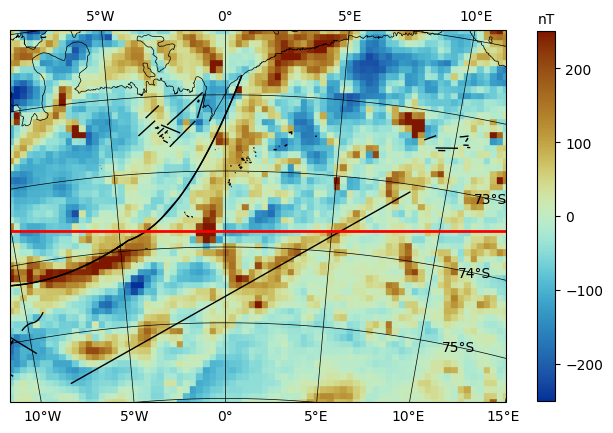

In [31]:
j = 43

sus_profil_ix = inv_sus[:, j, :]
line_x = (min(x_profil[0, :]), max(x_profil[0, :]))
line_y = (yq[j, 0], yq[j, 0])
dens_profil_ix = inv_dens[:, j, :]


## plot profile location
figure1 = plt.figure(figsize=(8, 8), facecolor="white")
ax1 = plt.subplot(1, 1, 1 , projection=ccrs.SouthPolarStereo())
Coastline.plot(ax=ax1 , color = 'k' , linewidth = 0.5)
faults_QML.plot(ax=ax1, color="k", linewidth=1)
ax1.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)

im1 = plt.scatter(
    X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=16, cmap=cmap_rev, vmin=-250, vmax=250)

axes = plt.gca()
cb1 = plt.colorbar(im1, shrink=.6, orientation="vertical")
cb1.ax.set_title("nT", fontsize=fontsize_index)
ax1.plot(line_x, line_y, color="r", linewidth=2)
plt.gca().set_aspect(1)
ax1.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax1.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())



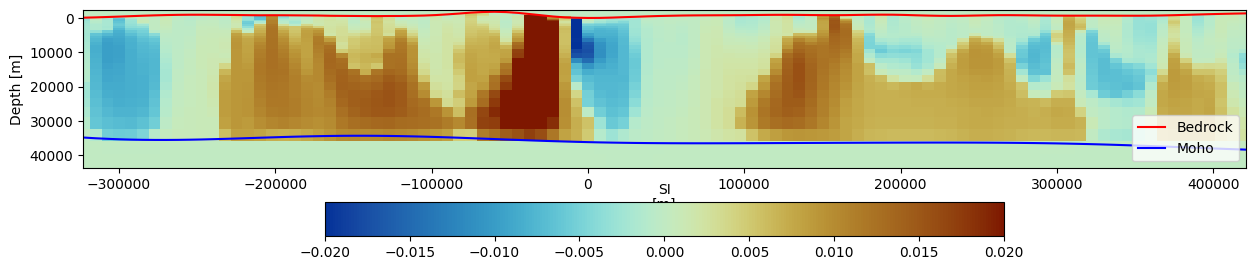

In [32]:
figure1 = plt.figure(figsize=(15, 10), facecolor="white")
# plot sus profil
ax2 = figure1.add_subplot(spec[1, :])

im2 = plt.pcolormesh(
    x_profil, z_profil, sus_profil_ix, cmap=cmap_rev, vmin=-0.02, vmax=0.02
)
plt.xlabel("[m]", fontsize=fontsize_index)
plt.ylabel("Depth [m]", fontsize=fontsize_index)
ax2.set_xlim([grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max()])


ax = plt.gca()
ax.invert_yaxis()
cb = plt.colorbar(im2, shrink=1, orientation="horizontal")
cb.ax.set_title(unit_sus, fontsize=fontsize_index)
plt.plot(x_profil[0, :], topointer[j, :] * -1, c="red", label="Bedrock")
# plt.plot(x_profil[0,:],CPDinter[j,:]*1000 , c='c' , label='CPD')
plt.plot(x_profil[0,:],Mohointer[j,:] * -1, c='blue', label='Moho')
ax2.legend(loc="lower right", prop={"size": 10})

(1565825.37326591, 2123650.66234)

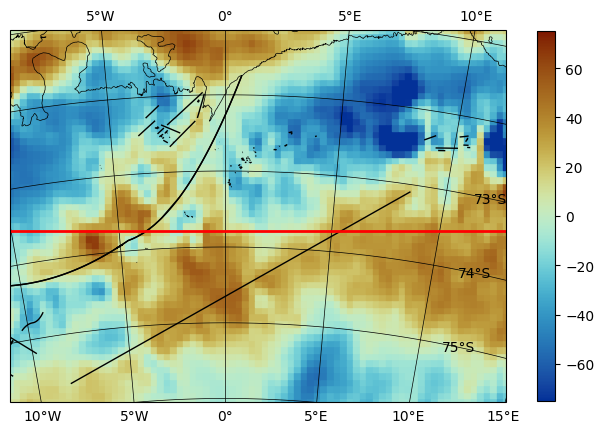

In [33]:
figure1 = plt.figure(figsize=(8, 8), facecolor="white")
ax3 = plt.subplot(1, 1, 1 , projection=ccrs.SouthPolarStereo())

im3 = plt.scatter(
    X_input_grav, Y_input_grav, c=val_input_grav, marker="s", s=16, cmap=cmap_rev, vmin =-75, vmax = 75)
Coastline.plot(ax=ax3 , color = 'k' , linewidth = 0.5)
faults_QML.plot(ax=ax3, color="k", linewidth=1)
ax3.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
axes = plt.gca()
cb3 = plt.colorbar(im3, shrink=.6, orientation="vertical")
# cb1.ax.set_title("mGal", fontsize=fontsize_index)
ax3.plot(line_x, line_y, color="r", linewidth=2)
plt.gca().set_aspect(1)
ax3.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax3.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())

  

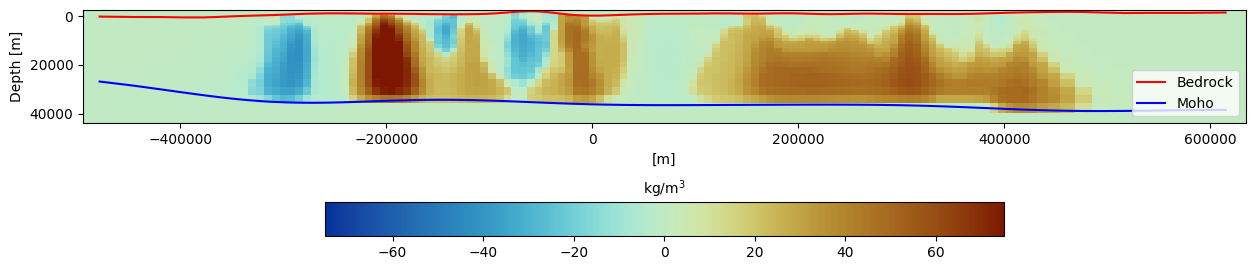

In [34]:
figure1 = plt.figure(figsize=(15, 10), facecolor="white")
# plot sus profil
ax4 = figure1.add_subplot(spec[1, :])

im4 = plt.pcolormesh(
    x_profil, z_profil, dens_profil_ix, cmap=cmap_rev, vmin=-75, vmax=75,
)
plt.xlabel("[m]", fontsize=fontsize_index)
plt.ylabel("Depth [m]", fontsize=fontsize_index)
ax2.set_xlim([grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max()])
ax = plt.gca()
ax.invert_yaxis()
cb = plt.colorbar(im4, shrink=1, orientation="horizontal", pad=0.35)
cb.ax.set_title(unit_dens, fontsize=fontsize_index)
plt.plot(x_profil[0, :], topointer[j, :] * -1, c="red", label="Bedrock")
plt.plot(x_profil[0,:],Mohointer[j,:]* -1 , c='blue', label='Moho')
ax4.legend(loc="lower right", prop={"size": 10})

In [35]:
# Merge data variables into one data container to identify profile coordinates and data
Mag_obs_merged = np.vstack((X_input_mag, Y_input_mag, val_input_mag)).T
Mag_syn_merged = np.vstack((X_syn_mag, Y_syn_mag, val_syn_mag)).T
Grav_obs_merged = np.vstack((X_input_grav, Y_input_grav, val_input_grav)).T
Grav_syn_merged = np.vstack((X_syn_grav, Y_syn_grav, val_syn_grav)).T


In [36]:
 line_y[0]

1822238.017802955

In [37]:
np.unique(Mag_obs_merged[:, 1])

masked_array(data=[1565825.37326591, 1565825.37326592, 1575611.78184615,
                   1575611.78184616, 1575611.78184617, 1585398.1904264 ,
                   1585398.19042641, 1595184.59900665, 1595184.59900666,
                   1604971.00758689, 1604971.0075869 , 1614757.41616714,
                   1614757.41616715, 1624543.82474738, 1624543.82474739,
                   1624543.8247474 , 1634330.23332763, 1634330.23332764,
                   1644116.64190788, 1644116.64190789, 1653903.05048812,
                   1653903.05048813, 1663689.45906837, 1663689.45906838,
                   1673475.86764861, 1673475.86764862, 1683262.27622886,
                   1683262.27622887, 1693048.68480911, 1693048.68480912,
                   1702835.09338935, 1702835.09338936, 1712621.5019696 ,
                   1712621.50196961, 1722407.91054984, 1722407.91054985,
                   1722407.91054986, 1732194.31913009, 1732194.3191301 ,
                   1741980.72771034, 1741980.727710

In [38]:
# find data points for horizontal profile

obs_mag_horizontal_profile_ix = []
for i in range(len(Mag_obs_merged[:, 0])):
    if Mag_obs_merged[i, 1] == 1830058.40493256:
        obs_mag_horizontal_profile_ix.append(Mag_obs_merged[i, :])
obs_mag_horizontal_profile = np.array(obs_mag_horizontal_profile_ix)


syn_mag_horizontal_profile_ix = []
for i in range(len(Mag_syn_merged[:, 0])):
    if Mag_syn_merged[i, 1] == 1830058.40493256:
        syn_mag_horizontal_profile_ix.append(Mag_syn_merged[i, :])
syn_mag_horizontal_profile = np.array(syn_mag_horizontal_profile_ix)


obs_grav_horizontal_profile_ix = []
for i in range(len(Grav_obs_merged[:, 0])):
    if Grav_obs_merged[i, 1] == 1830058.40493256:
        obs_grav_horizontal_profile_ix.append(Grav_obs_merged[i, :])
obs_grav_horizontal_profile = np.array(obs_grav_horizontal_profile_ix)


syn_grav_horizontal_profile_ix = []
for i in range(len(Grav_syn_merged[:, 0])):
    if Grav_syn_merged[i, 1] == 1830058.40493256:
        syn_grav_horizontal_profile_ix.append(Grav_syn_merged[i, :])
syn_grav_horizontal_profile = np.array(syn_grav_horizontal_profile_ix)

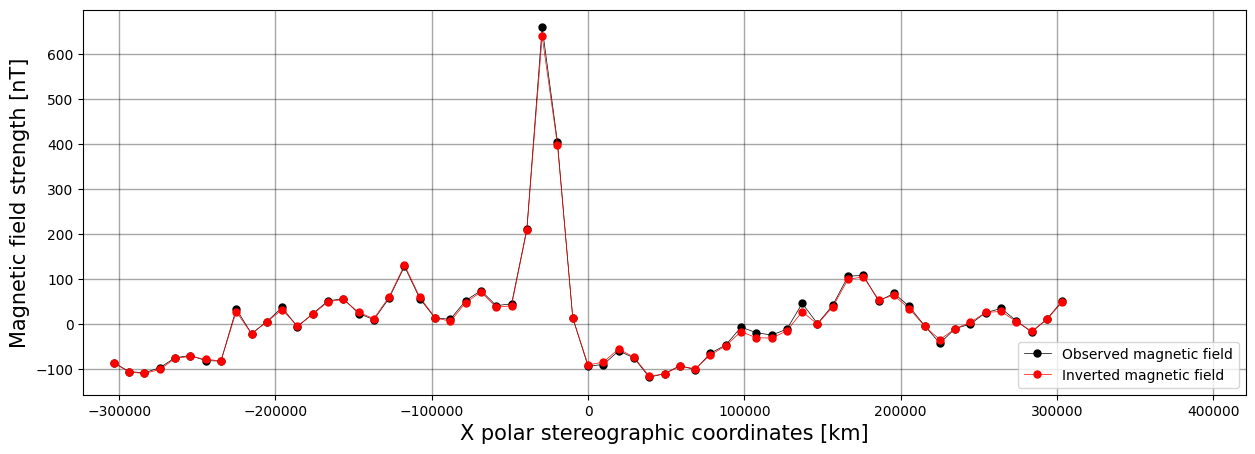

In [39]:
figure1 = plt.figure(figsize=(15, 5), facecolor="white")
ax2 = plt.subplot(1, 1, 1)
plt.plot(
    obs_mag_horizontal_profile[:, 0],
    obs_mag_horizontal_profile[:, 2],
    "o-k",
    linewidth=0.5,
    markersize=5,
    label="Observed magnetic field",
)
plt.plot(
    syn_mag_horizontal_profile[:, 0],
    syn_mag_horizontal_profile[:, 2],
    "o-r",
    linewidth=0.5,
    markersize=5,
    label="Inverted magnetic field",
)
ax2.set_xlim([grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max()])
ax2.legend(loc="lower right", prop={"size": 10})
ax2.set_ylabel("Magnetic field strength [nT]", fontsize=15)
ax2.set_xlabel("X polar stereographic coordinates [km]", fontsize=15)
ax2.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")
# plt.savefig(
#     export_profiles + "magnetic_data_points_along_horizontal_profile.png",
#     facecolor=figure1.get_facecolor(),
#     transparent=True,
# )

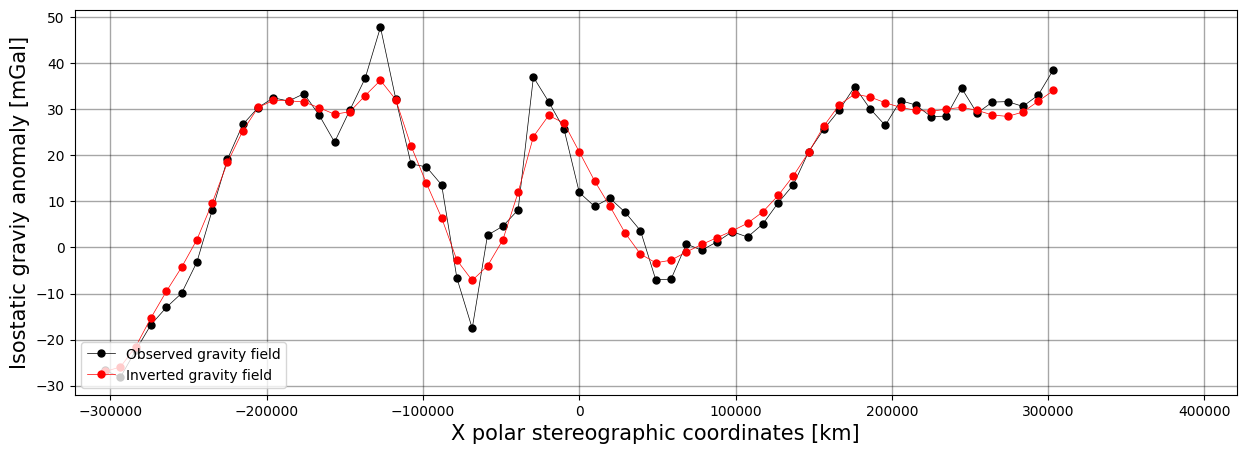

In [40]:
figure1 = plt.figure(figsize=(15, 5), facecolor="white")
ax2 = plt.subplot(1, 1, 1)
plt.plot(
    obs_grav_horizontal_profile[:, 0] ,
    obs_grav_horizontal_profile[:, 2],
    "o-k",
    linewidth=0.5,
    markersize=5,
    label="Observed gravity field",
)
plt.plot(
    syn_grav_horizontal_profile[:, 0] ,
    syn_grav_horizontal_profile[:, 2],
    "o-r",
    linewidth=0.5,
    markersize=5,
    label="Inverted gravity field",
)
ax2.set_xlim([grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max()])
ax2.legend(loc="lower left", prop={"size": 10})
ax2.set_ylabel("Isostatic graviy anomaly [mGal]", fontsize=15)
ax2.set_xlabel("X polar stereographic coordinates [km]", fontsize=15)
ax2.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")
# plt.savefig(
#     export_profiles + "gravity_data_points_along_horizontal_profile.png",
#     facecolor=figure1.get_facecolor(),
#     transparent=True,
# )

In [41]:
Coastline = gpd.read_file('DATA/ADD_Coastline.gpkg')

In [42]:
x_study_area = [grav_mag_pd.x_ps.min(),  grav_mag_pd.x_ps.max(),  grav_mag_pd.x_ps.max(), grav_mag_pd.x_ps.min(), grav_mag_pd.x_ps.min()]
y_study_area = [grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max(), grav_mag_pd.y_ps.max(), grav_mag_pd.y_ps.min()]

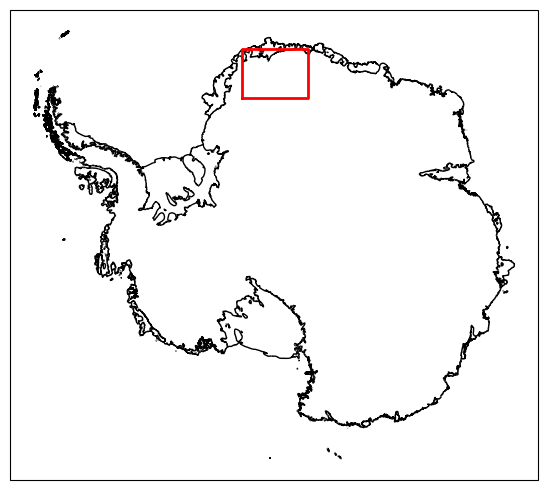

In [43]:
figure1 = plt.figure(figsize=(15, 15), facecolor="white")

ax1 = plt.subplot(1, 2, 1,  projection=ccrs.SouthPolarStereo())

Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
ax1.plot(x_study_area, y_study_area,color="r", linewidth=2)


# Diagonal plot

In [44]:
topointer = griddata(
    (Boundaries.x_ps, Boundaries.y_ps),
    Boundaries.BED_filt,
    (xq, yq),
    method="linear",
)

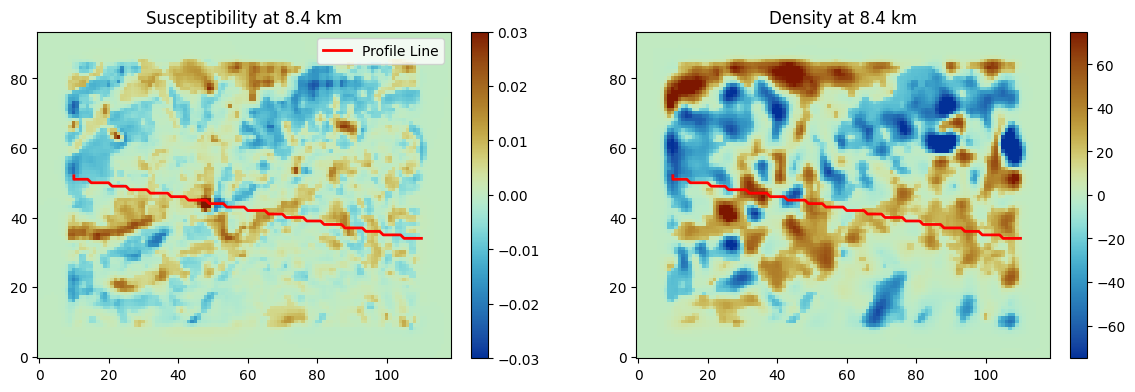

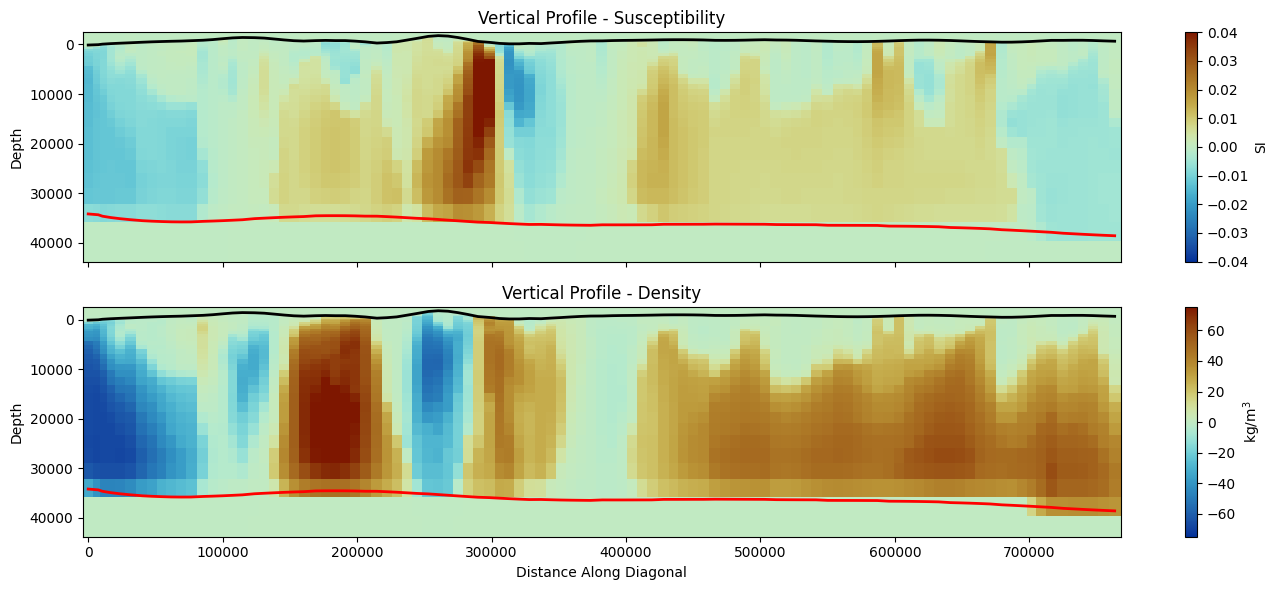

In [139]:
# --- Mesh and dimensions ---
Zg, Yg, Xg = np.meshgrid(Depth_sus, Y_sus, X_sus, indexing='ij')
Nz, Ny, Nx = inv_sus.shape

# --- Define diagonal profile start and end points ---
# start_x, start_y = 7, 65
# end_x, end_y = 110, 11

# start_x, start_y = 7, 75
# end_x, end_y = 90, 11

# start_x, start_y = 7, 62
# end_x, end_y = 110, 32

# start_x, start_y = 40, 85
# end_x, end_y = 80, 8

# start_x, start_y = 7, 48
# end_x, end_y = 110, 38

# start_x, start_y = 7, 68
# end_x, end_y = 110, 38

# start_x, start_y = 10, 50
# end_x, end_y = 80, 8

# start_x, start_y = 10, 60
# end_x, end_y = 110, 40

# start_x, start_y = 7, 45
# end_x, end_y = 110, 45


# start_x, start_y = 7, 68 
# end_x, end_y = 110, 38


start_x, start_y = 10, 52
end_x, end_y = 110, 34

num_points = int(np.hypot(end_x - start_x, end_y - start_y)) + 1
x_line = np.linspace(start_x, end_x, num_points).astype(int)
y_line = np.linspace(start_y, end_y, num_points).astype(int)

# --- Extract profile values ---
vertical_section_sus = np.zeros((Nz, num_points))
vertical_section_dens = np.zeros((Nz, num_points))
x_coords = np.zeros((Nz, num_points))
z_coords = np.zeros((Nz, num_points))

for i in range(num_points):
    x = x_line[i]
    y = y_line[i]
    vertical_section_sus[:, i] = inv_sus[:, y, x]
    vertical_section_dens[:, i] = inv_dens[:, y, x]
    x_coords[:, i] = Xg[:, y, x]
    z_coords[:, i] = Zg[:, y, x]

    
topo_profile = np.zeros(num_points)
for i in range(num_points):
    x = x_line[i]
    y = y_line[i]
    topo_profile[i] = topointer[y, x]
topo_depth = topo_profile*-1

moho_profile = np.zeros(num_points)
for i in range(num_points):
    x = x_line[i]
    y = y_line[i]
    moho_profile[i] = Mohointer[y, x]
moho_depth = moho_profile*-1

    
# --- Compute horizontal distance along diagonal ---
x_pos = Xg[0, y_line, x_line]
y_pos = Yg[0, y_line, x_line]
dist_along = np.sqrt((x_pos - x_pos[0])**2 + (y_pos - y_pos[0])**2)

# --- Plot horizontal map with diagonal line ---
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
depth_ix = 25

xy_plane_sus = inv_sus[depth_ix, :, :]
xy_plane_dens = inv_dens[depth_ix, :, :]

im0 = axs[0].imshow(xy_plane_sus, origin='lower', cmap=cmap_rev, vmin=-0.03, vmax=0.03)
axs[0].plot(x_line, y_line, 'r-', lw=2, label='Profile Line')
axs[0].set_title(f"Susceptibility at {Depth_sus[depth_ix]/1000:.1f} km")
axs[0].legend()
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(xy_plane_dens, origin='lower', cmap=cmap_rev, vmin=-75, vmax=75)
axs[1].plot(x_line, y_line, 'r-', lw=2)
axs[1].set_title(f"Density at {Depth_sus[depth_ix]/1000:.1f} km")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# --- Plot vertical profiles (depth vs distance) ---
fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

im0 = axs[0].pcolormesh(dist_along, Depth_sus, vertical_section_sus, cmap=cmap_rev, shading='auto', vmin=-0.04, vmax=0.04)
axs[0].plot(dist_along, topo_depth, 'k', lw=2)
axs[0].plot(dist_along, moho_depth, 'r', lw=2)
axs[0].invert_yaxis()
axs[0].set_ylabel('Depth')
axs[0].set_title('Vertical Profile - Susceptibility')
fig.colorbar(im0, ax=axs[0], label='SI')

im1 = axs[1].pcolormesh(dist_along, Depth_sus, vertical_section_dens, cmap=cmap_rev, shading='auto', vmin=-75, vmax=75)
axs[1].plot(dist_along, topo_depth, 'k', lw=2)
axs[1].plot(dist_along, moho_depth, 'r', lw=2)
axs[1].invert_yaxis()
axs[1].set_xlabel('Distance Along Diagonal')
axs[1].set_ylabel('Depth')
axs[1].set_title('Vertical Profile - Density')
fig.colorbar(im1, ax=axs[1], label='kg/m$^3$')


plt.tight_layout()
plt.show()

In [140]:
physical_coords = np.column_stack((Xg[0, y_line, x_line], Yg[0, y_line, x_line]))


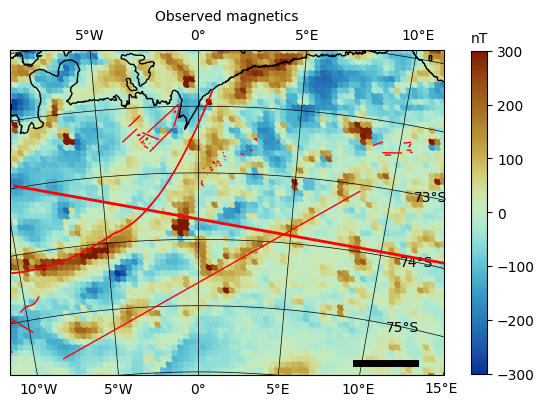

In [141]:
figure1 = plt.figure(figsize=(7, 7), facecolor="white")

ax4 = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
plt.title("Observed magnetics", fontsize=10)
im4 = plt.scatter(X_syn_grav , Y_syn_grav ,25, c=val_input_mag , cmap=cmap_rev, vmin = -300, vmax = 300)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im4, shrink=0.6)
cb.ax.set_title("nT", fontsize=10)
ax4.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax4.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax4.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax4 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax4, color="red", linewidth=1)
ax4.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar

ax4.plot([physical_coords[0,0],physical_coords[-1,0]], [physical_coords[0,1],physical_coords[-1,1]], 'r-', lw=2, label='Profile Line')


In [142]:
# Preallocate array for nearest values
nearest_obs_mag_values = np.zeros(physical_coords.shape[0])

for i, (px, py) in enumerate(physical_coords):
    # Compute Euclidean distance from all magnetic points to the profile point
    distances = np.sqrt((Mag_obs_merged[:, 0] - px)**2 + (Mag_obs_merged[:, 1] - py)**2)
    
    # Find the index of the closest point
    idx = np.argmin(distances)
    
    # Store the value of the closest magnetic point
    nearest_obs_mag_values[i] = Mag_obs_merged[idx, 2]
    
    

nearest_syn_mag_values = np.zeros(physical_coords.shape[0])

for i, (px, py) in enumerate(physical_coords):
    # Compute Euclidean distance from all magnetic points to the profile point
    distances = np.sqrt((Mag_syn_merged[:, 0] - px)**2 + (Mag_syn_merged[:, 1] - py)**2)
    
    # Find the index of the closest point
    idx = np.argmin(distances)
    
    # Store the value of the closest magnetic point
    nearest_syn_mag_values[i] = Mag_syn_merged[idx, 2]
    
    
    
    
    

# Preallocate array for nearest values
nearest_obs_Grav_values = np.zeros(physical_coords.shape[0])

for i, (px, py) in enumerate(physical_coords):
    # Compute Euclidean distance from all Gravnetic points to the profile point
    distances = np.sqrt((Grav_obs_merged[:, 0] - px)**2 + (Grav_obs_merged[:, 1] - py)**2)
    
    # Find the index of the closest point
    idx = np.argmin(distances)
    
    # Store the value of the closest Gravnetic point
    nearest_obs_Grav_values[i] = Grav_obs_merged[idx, 2]
    
    

nearest_syn_Grav_values = np.zeros(physical_coords.shape[0])

for i, (px, py) in enumerate(physical_coords):
    # Compute Euclidean distance from all Gravnetic points to the profile point
    distances = np.sqrt((Grav_syn_merged[:, 0] - px)**2 + (Grav_syn_merged[:, 1] - py)**2)
    
    # Find the index of the closest point
    idx = np.argmin(distances)
    
    # Store the value of the closest Gravnetic point
    nearest_syn_Grav_values[i] = Grav_syn_merged[idx, 2]
    

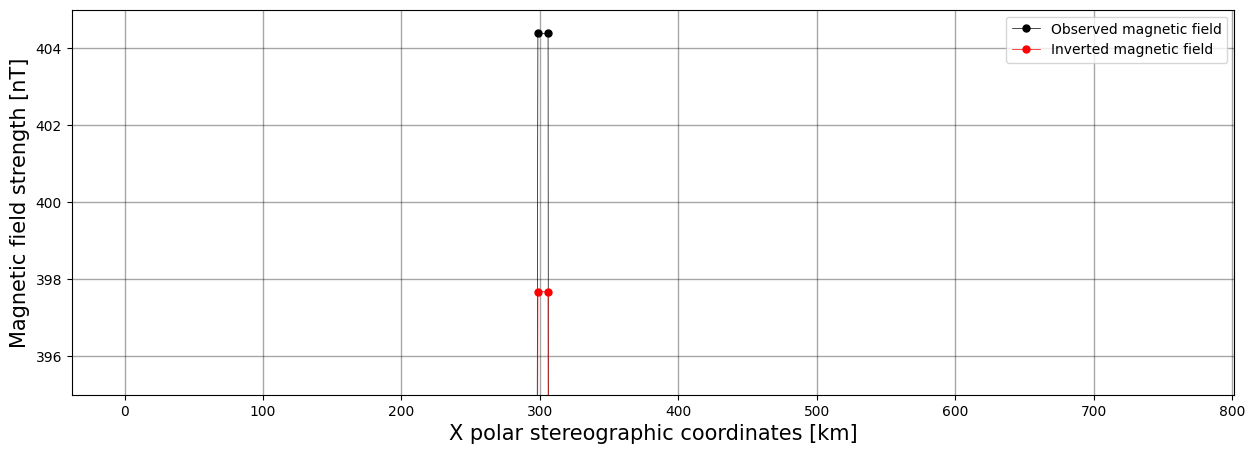

In [154]:
# Compute distance along the profile
dist_along = np.sqrt((physical_coords[:,0] - physical_coords[0,0])**2 +
                     (physical_coords[:,1] - physical_coords[0,1])**2)

figure1 = plt.figure(figsize=(15, 5), facecolor="white")
ax2 = plt.subplot(1, 1, 1)
plt.plot(dist_along/1000, nearest_obs_mag_values,
    "o-k",
    linewidth=0.5,
    markersize=5,
    label="Observed magnetic field",
)
plt.plot(dist_along/1000, nearest_syn_mag_values,
    "o-r",
    linewidth=0.5,
    markersize=5,
    label="Inverted magnetic field",
)
ax2.legend(loc="upper right", prop={"size": 10})
ax2.set_ylabel("Magnetic field strength [nT]", fontsize=15)
ax2.set_xlabel("X polar stereographic coordinates [km]", fontsize=15)
ax2.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")
# plt.ylim(395,405)

plt.savefig(inv_run+'Output/Figure/profil_mag_field.png',facecolor=figure1.get_facecolor(), transparent=True)


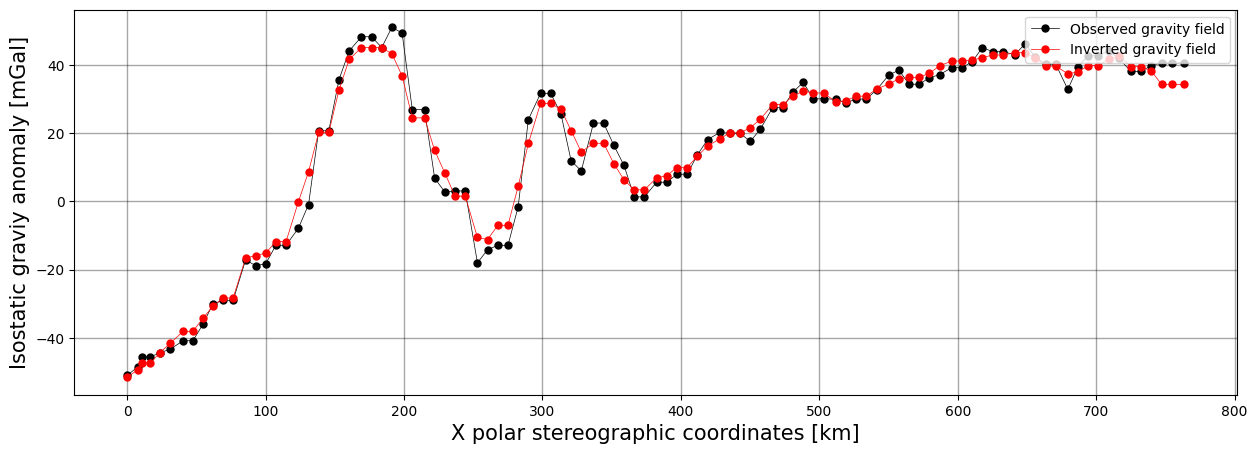

In [144]:
figure1 = plt.figure(figsize=(15, 5), facecolor="white")
ax2 = plt.subplot(1, 1, 1)
plt.plot(dist_along/1000, nearest_obs_Grav_values,
    "o-k",
    linewidth=0.5,
    markersize=5,
    label="Observed gravity field",
)
plt.plot(dist_along/1000, nearest_syn_Grav_values,
    "o-r",
    linewidth=0.5,
    markersize=5,
    label="Inverted gravity field",
)
ax2.legend(loc="upper right", prop={"size": 10})
ax2.set_ylabel("Isostatic graviy anomaly [mGal]", fontsize=15)
ax2.set_xlabel("X polar stereographic coordinates [km]", fontsize=15)
ax2.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")

plt.savefig(inv_run+'Output/Figure/profil_grav_field.png',facecolor=figure1.get_facecolor(), transparent=True)


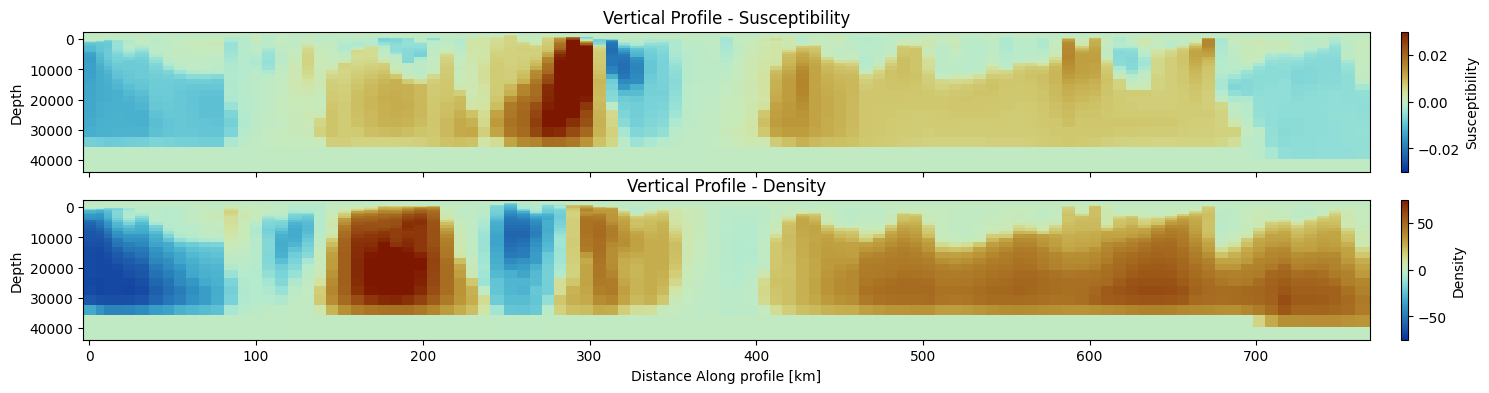

In [145]:

# --- Plot vertical profiles (depth vs distance) ---
fig, axs = plt.subplots(2, 1, figsize=(20, 4), sharex=True)

im0 = axs[0].pcolormesh(dist_along/1000, Depth_sus, vertical_section_sus, cmap=cmap_rev, shading='auto', vmin=-0.03, vmax=0.03)
# axs[0].plot(dist_along, topo_depth, 'k', lw=2)
# axs[0].plot(dist_along, moho_depth, 'r', lw=2)
axs[0].invert_yaxis()
axs[0].set_ylabel('Depth')
axs[0].set_title('Vertical Profile - Susceptibility')
fig.colorbar(im0, ax=axs[0], label='Susceptibility', pad=0.02)

im1 = axs[1].pcolormesh(dist_along/1000, Depth_sus, vertical_section_dens, cmap=cmap_rev, shading='auto', vmin=-75, vmax=75)
# axs[1].plot(dist_along, topo_depth, 'k', lw=2)
# axs[1].plot(dist_along, moho_depth, 'r', lw=2)
axs[1].invert_yaxis()
axs[1].set_xlabel('Distance Along profile [km]')
axs[1].set_ylabel('Depth')
axs[1].set_title('Vertical Profile - Density')
fig.colorbar(im1, ax=axs[1], label='Density', pad=0.02)
plt.savefig(inv_run+'Output/Figure/inv_profiles_colorbar.png',facecolor=figure1.get_facecolor(), transparent=True)



In [146]:
x_pos = Xg[0, y_line, x_line]
y_pos = Yg[0, y_line, x_line]
dist_along = np.sqrt((x_pos - x_pos[0])**2 + (y_pos - y_pos[0])**2)

In [147]:
marker_spacing = 100_000  # 200 km in meters
markers = np.arange(0, dist_along[-1], marker_spacing)

In [148]:
x_mark = np.interp(markers, dist_along, x_pos)
y_mark = np.interp(markers, dist_along, y_pos)

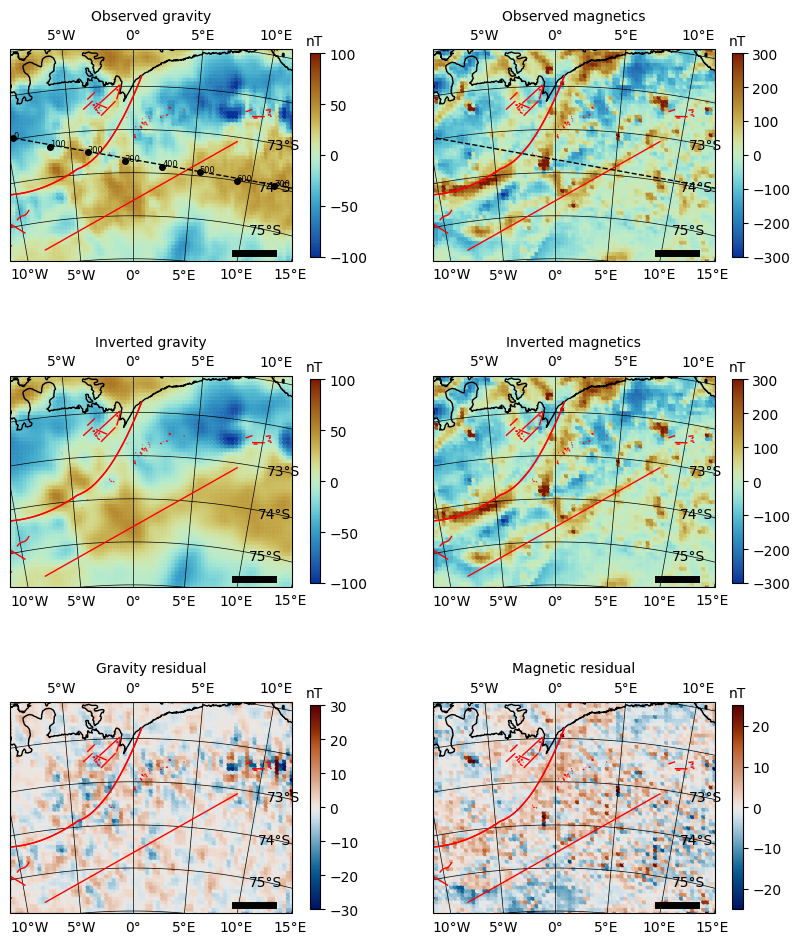

In [149]:
# create figure
figure1 = plt.figure(figsize=(10, 12), facecolor="white")

# grav data
ax1 = plt.subplot(3, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Observed gravity", fontsize=10)
im1 = plt.scatter(X_input_grav , Y_input_grav , 7, c=val_input_grav , cmap=cmap_rev, vmin =-100, vmax=100 )
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im1, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax1.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax1.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax1.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="red", linewidth=1)
ax1.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar
ax1.plot([physical_coords[0,0],physical_coords[-1,0]], [physical_coords[0,1],physical_coords[-1,1]], 'k--', lw=1, label='Profile Line')
ax1.plot(x_mark, y_mark, 'ko', markersize=4)  # dots
# optional: label them
for i, d in enumerate(markers):
    ax1.text(x_mark[i], y_mark[i], f"{int(d/1000)}", fontsize=6)


ax2 = plt.subplot(3, 2, 3, projection=ccrs.SouthPolarStereo())
plt.title("Inverted gravity", fontsize=10)
im2 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_syn_grav , cmap=cmap_rev, vmin =-100, vmax=100 )
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im2, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax2.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax2.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax2.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax2 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax2, color="red", linewidth=1)
ax2.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar


ax3 = plt.subplot(3, 2, 5, projection=ccrs.SouthPolarStereo())
plt.title("Gravity residual", fontsize=10)
im3 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_input_grav-val_syn_grav , cmap=cmap_diff, vmin=-30, vmax=30)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im3, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax3.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax3.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax3.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax3 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax3, color="red", linewidth=1)
ax3.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar

ax4 = plt.subplot(3, 2, 2, projection=ccrs.SouthPolarStereo())
plt.title("Observed magnetics", fontsize=10)
im4 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_input_mag , cmap=cmap_rev, vmin = -300, vmax = 300)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im4, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax4.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax4.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax4.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax4 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax4, color="red", linewidth=1)
ax4.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar
ax4.plot([physical_coords[0,0],physical_coords[-1,0]], [physical_coords[0,1],physical_coords[-1,1]], 'k--', lw=1, label='Profile Line')


ax5 = plt.subplot(3, 2, 4, projection=ccrs.SouthPolarStereo())
plt.title("Inverted magnetics", fontsize=10)
im5 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_syn_mag , cmap=cmap_rev , vmin = -300, vmax = 300)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im5, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax5.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax5.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax5.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax5 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax5, color="red", linewidth=1)
ax5.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar


ax6 = plt.subplot(3, 2, 6, projection=ccrs.SouthPolarStereo())
plt.title("Magnetic residual", fontsize=10)
im6 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_input_mag-val_syn_mag , cmap=cmap_diff, vmin = -25, vmax = 25)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im6, shrink=0.75)
cb.ax.set_title("nT", fontsize=10)
ax6.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax6.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax6.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax6 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax6, color="red", linewidth=1)
ax6.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar


# plt.savefig(inv_run+'Output/Figure/VI_inversion_maps_with_profil_location_profile_dots.png',facecolor=figure1.get_facecolor(), transparent=True)


In [150]:
sdfsdf

NameError: name 'sdfsdf' is not defined

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- Create figure with custom gridspec ---
fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = gridspec.GridSpec(4, 1, height_ratios=[1.5, 1.5, 1.5, 1.5], hspace=0.3)

# --- Magnetic profile ---
ax_mag = fig.add_subplot(gs[0, 0])
ax_mag.plot(dist_along/1000, nearest_obs_mag_values, "o-k", linewidth=0.5, markersize=5, label="Observed magnetic field")
ax_mag.plot(dist_along/1000, nearest_syn_mag_values, "o-r", linewidth=0.5, markersize=5, label="Inverted magnetic field")
ax_mag.set_ylabel("Magnetic [nT]", fontsize=12)
ax_mag.legend(loc="upper right", fontsize=10)
ax_mag.grid(alpha=0.5)
ax_mag.set_title('Magnetic', fontsize=12)


# --- Gravity profile ---
ax_grav = fig.add_subplot(gs[1, 0], sharex=ax_mag)
ax_grav.plot(dist_along/1000, nearest_obs_Grav_values, "o-k", linewidth=0.5, markersize=5, label="Observed gravity")
ax_grav.plot(dist_along/1000, nearest_syn_Grav_values, "o-r", linewidth=0.5, markersize=5, label="Inverted gravity")
ax_grav.set_ylabel("Gravity [mGal]", fontsize=12)
ax_grav.legend(loc="lower right", fontsize=10)
ax_grav.grid(alpha=0.5)
ax_grav.set_title('Gravity', fontsize=12)


# --- Susceptibility vertical profile ---
ax_sus = fig.add_subplot(gs[2, 0], sharex=ax_mag)
im_sus = ax_sus.pcolormesh(dist_along/1000, Depth_sus, vertical_section_sus,
                            cmap=cmap_rev, shading='auto', vmin=-0.03, vmax=0.03)
ax_sus.plot(dist_along/1000, topo_depth, 'k', lw=2, label="Topography")
ax_sus.plot(dist_along/1000, moho_depth, 'r', lw=2, label="Moho")
ax_sus.legend(loc="upper right", fontsize=10)
ax_sus.invert_yaxis()
ax_sus.set_ylabel('Depth [km]', fontsize=12)
ax_sus.set_title('Susceptibility', fontsize=12)
ax_sus.grid(alpha=0.5)

levels = [0.04]


cs = ax_sus.contour(
    dist_along/1000,
    Depth_sus,
    vertical_section_sus,
    levels=levels,
    colors='black',
    linewidths=1.0
)

ax_sus.clabel(cs, inline=True, fontsize=8, fmt="%.3f")


# --- Density vertical profile ---
ax_dens = fig.add_subplot(gs[3, 0], sharex=ax_mag)
im_dens = ax_dens.pcolormesh(dist_along/1000, Depth_sus, vertical_section_dens,
                             cmap=cmap_rev, shading='auto', vmin=-75, vmax=75)
ax_dens.plot(dist_along/1000, topo_depth, 'k', lw=2, label="Topography")
ax_dens.plot(dist_along/1000, moho_depth, 'r', lw=2, label="Moho")
ax_dens.legend(loc="upper right", fontsize=10)
ax_dens.invert_yaxis()
ax_dens.set_ylabel('Depth [km]', fontsize=12)
ax_dens.set_xlabel('Distance along profile [km]', fontsize=12)
ax_dens.set_title('Density', fontsize=12)
ax_dens.grid(alpha=0.5)

# levels_dens = [10,30,50]
# cs = ax_dens.contour(
#     dist_along/1000,
#     Depth_sus,
#     vertical_section_dens,
#     levels=levels_dens,
#     colors='black',
#     linewidths=1.0
# )

# ax_dens.clabel(cs, inline=True, fontsize=8, fmt="%.0f")


# --- Make x-ticks appear in increments of 100 km ---
xticks = np.arange(0, dist_along.max()/1000, 100)  # 0, 100, 200, ... km
for ax in [ax_mag, ax_grav, ax_sus, ax_dens]:
    ax.set_xticks(xticks)

# --- Hide x-axis labels for top three subplots for cleaner look ---
for ax in [ax_mag, ax_grav, ax_sus]:
    ax.label_outer()

# plt.savefig(inv_run+'Output/Figure/profils.png',facecolor=figure1.get_facecolor(), transparent=True)


## SI profile plots

In [ ]:
# --- Mesh and dimensions ---
Zg, Yg, Xg = np.meshgrid(Depth_sus, Y_sus, X_sus, indexing='ij')
Nz, Ny, Nx = inv_sus.shape

# --- Define diagonal profile start and end points ---

# start_x, start_y = 7, 68 BIF
# end_x, end_y = 110, 38


# start_x, start_y = 10, 50
# end_x, end_y = 80, 8

# start_x, start_y = 7, 65
# end_x, end_y = 110, 11


start_x, start_y = 7, 44
end_x, end_y = 110, 44


num_points = int(np.hypot(end_x - start_x, end_y - start_y)) + 1
x_line = np.linspace(start_x, end_x, num_points).astype(int)
y_line = np.linspace(start_y, end_y, num_points).astype(int)

# --- Extract profile values ---
vertical_section_sus = np.zeros((Nz, num_points))
vertical_section_dens = np.zeros((Nz, num_points))
x_coords = np.zeros((Nz, num_points))
z_coords = np.zeros((Nz, num_points))

for i in range(num_points):
    x = x_line[i]
    y = y_line[i]
    vertical_section_sus[:, i] = inv_sus[:, y, x]
    vertical_section_dens[:, i] = inv_dens[:, y, x]
    x_coords[:, i] = Xg[:, y, x]
    z_coords[:, i] = Zg[:, y, x]

    
topo_profile = np.zeros(num_points)
for i in range(num_points):
    x = x_line[i]
    y = y_line[i]
    topo_profile[i] = topointer[y, x]
topo_depth = topo_profile*-1

moho_profile = np.zeros(num_points)
for i in range(num_points):
    x = x_line[i]
    y = y_line[i]
    moho_profile[i] = Mohointer[y, x]
moho_depth = moho_profile*-1

    
# --- Compute horizontal distance along diagonal ---
x_pos = Xg[0, y_line, x_line]
y_pos = Yg[0, y_line, x_line]
dist_along = np.sqrt((x_pos - x_pos[0])**2 + (y_pos - y_pos[0])**2)

In [ ]:
# create figure
figure1 = plt.figure(figsize=(10, 12), facecolor="white")

# grav data
ax1 = plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Observed gravity", fontsize=10)
im1 = ax1.scatter(X_input_grav , Y_input_grav , 7, c=val_input_grav , cmap=cmap_rev, vmin =-100, vmax=100 )
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im1, shrink=0.25)
cb.ax.set_title("nT", fontsize=10)
ax1.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax1.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax1.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="red", linewidth=1)
ax1.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar
ax1.plot([physical_coords[0,0],physical_coords[-1,0]], [physical_coords[0,1],physical_coords[-1,1]], 'k--', lw=2, label='Profile Line')
ax1.plot(x_mark, y_mark, 'ko', markersize=4)  # dots
# optional: label them
for i, d in enumerate(markers):
    ax1.text(x_mark[i], y_mark[i]+20000, f"{int(d/1000)}", fontsize=6)


ax4 = plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
plt.title("Observed magnetics", fontsize=10)
im4 = plt.scatter(X_syn_grav , Y_syn_grav , 7, c=val_input_mag , cmap=cmap_rev, vmin = -300, vmax = 300)
axes = plt.gca()
axes.set_aspect(1)
cb = plt.colorbar(im4, shrink=0.25)
cb.ax.set_title("nT", fontsize=10)
ax4.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)
ax4.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax4.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())
Coastline.plot(ax=ax4 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax4, color="red", linewidth=1)
ax4.plot(
    [X_input_grav.max()-50000 -100000, X_input_grav.max()-50000 ], [Y_input_grav.min()+20000, Y_input_grav.min()+20000], "-k", linewidth=5
)  # 300 km scale bar
ax4.plot([physical_coords[0,0],physical_coords[-1,0]], [physical_coords[0,1],physical_coords[-1,1]], 'k--', lw=2, label='Profile Line')
ax4.plot(x_mark, y_mark, 'ko', markersize=4)  # dots
# optional: label them
for i, d in enumerate(markers):
    ax4.text(x_mark[i], y_mark[i]+20000, f"{int(d/1000)}", fontsize=6)


plt.savefig(inv_run+'Output/Figure/supporting_info_thrust3.png',facecolor=figure1.get_facecolor(), transparent=True)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- Create figure with custom gridspec ---
fig = plt.figure(figsize=(18, 12), facecolor="white")
gs = gridspec.GridSpec(4, 1, height_ratios=[1.5, 1.5, 1.5, 1.5], hspace=0.3)

# --- Magnetic profile ---
ax_mag = fig.add_subplot(gs[0, 0])
ax_mag.plot(dist_along/1000, nearest_obs_mag_values, "o-k", linewidth=0.5, markersize=5, label="Observed magnetic field")
ax_mag.plot(dist_along/1000, nearest_syn_mag_values, "o-r", linewidth=0.5, markersize=5, label="Inverted magnetic field")
ax_mag.set_ylabel("Magnetic [nT]", fontsize=12)
ax_mag.legend(loc="upper right", fontsize=10)
ax_mag.grid(alpha=0.5)
ax_mag.set_title('Magnetic', fontsize=12)


# --- Gravity profile ---
ax_grav = fig.add_subplot(gs[1, 0], sharex=ax_mag)
ax_grav.plot(dist_along/1000, nearest_obs_Grav_values, "o-k", linewidth=0.5, markersize=5, label="Observed gravity")
ax_grav.plot(dist_along/1000, nearest_syn_Grav_values, "o-r", linewidth=0.5, markersize=5, label="Inverted gravity")
ax_grav.set_ylabel("Gravity [mGal]", fontsize=12)
ax_grav.legend(loc="lower right", fontsize=10)
ax_grav.grid(alpha=0.5)
ax_grav.set_title('Gravity', fontsize=12)


# --- Susceptibility vertical profile ---
ax_sus = fig.add_subplot(gs[2, 0], sharex=ax_mag)
im_sus = ax_sus.pcolormesh(dist_along/1000, Depth_sus, vertical_section_sus,
                            cmap=cmap_rev, shading='auto', vmin=-0.03, vmax=0.03)
ax_sus.plot(dist_along/1000, topo_depth, 'k', lw=2, label="Topography")
ax_sus.plot(dist_along/1000, moho_depth, 'r', lw=2, label="Moho")
ax_sus.legend(loc="upper right", fontsize=10)
ax_sus.invert_yaxis()
ax_sus.set_ylabel('Depth [km]', fontsize=12)
ax_sus.set_title('Susceptibility', fontsize=12)
ax_sus.grid(alpha=0.5)

# levels = [0, 0.005, 0.01, 0.015 ,0.02 ,0.03, 0.04,  0.05]


# cs = ax_sus.contour(
#     dist_along/1000,
#     Depth_sus,
#     vertical_section_sus,
#     levels=levels,
#     colors='black',
#     linewidths=1.0
# )

# ax_sus.clabel(cs, inline=True, fontsize=8, fmt="%.3f")


# --- Density vertical profile ---
ax_dens = fig.add_subplot(gs[3, 0], sharex=ax_mag)
im_dens = ax_dens.pcolormesh(dist_along/1000, Depth_sus, vertical_section_dens,
                             cmap=cmap_rev, shading='auto', vmin=-75, vmax=75)
ax_dens.plot(dist_along/1000, topo_depth, 'k', lw=2, label="Topography")
ax_dens.plot(dist_along/1000, moho_depth, 'r', lw=2, label="Moho")
ax_dens.legend(loc="upper right", fontsize=10)
ax_dens.invert_yaxis()
ax_dens.set_ylabel('Depth [km]', fontsize=12)
ax_dens.set_xlabel('Distance along profile [km]', fontsize=12)
ax_dens.set_title('Density', fontsize=12)
ax_dens.grid(alpha=0.5)

# levels_dens = [10,30,50]
# cs = ax_dens.contour(
#     dist_along/1000,
#     Depth_sus,
#     vertical_section_dens,
#     levels=levels_dens,
#     colors='black',
#     linewidths=1.0
# )

# ax_dens.clabel(cs, inline=True, fontsize=8, fmt="%.0f")


# --- Make x-ticks appear in increments of 100 km ---
xticks = np.arange(0, dist_along.max()/1000, 100)  # 0, 100, 200, ... km
for ax in [ax_mag, ax_grav, ax_sus, ax_dens]:
    ax.set_xticks(xticks)

# --- Hide x-axis labels for top three subplots for cleaner look ---
for ax in [ax_mag, ax_grav, ax_sus]:
    ax.label_outer()

plt.savefig(inv_run+'Output/Figure/profils_thrust3.png',facecolor=figure1.get_facecolor(), transparent=True)


# Density susceptibility relationship

In [ ]:
VI_cov = nc4.Dataset(inv_run +'VI_inversion/Susceptibility_cov.nc') 
XX_mag_mesh = VI_cov.variables['Northing'][:]
YY_mag_mesh = VI_cov.variables['Easting'][:]
VI_cov_mesh = VI_cov.variables['Susceptibility'][:]

VI_cov.close()

In [ ]:
export_data_path = inv_run + 'Output/Data/'

# Create path if it does not exists
if not os.path.exists(export_data_path):
    os.makedirs(export_data_path)
    
export_fig_path_histogramms = inv_run + 'Output/Figure/histogramms/'

# Create path if it does not exists
if not os.path.exists(export_fig_path_histogramms):
    os.makedirs(export_fig_path_histogramms)

In [ ]:
xq , yq = np.meshgrid(X_sus , Y_sus)
# Depth_inversion_km = np.round((Depth_sus/1000),1)
Depth_inversion_km = Depth_sus/1000

In [ ]:
d= np.zeros(np.shape(inv_dens))
depths =  np.append(Depth_sus_Origin,Depth_sus)
for i in range(len(d)):
    d[i]=depths[i]/1000

In [ ]:
x_stack_ix = []
y_stack_ix = []
z_stack_ix = []

for i in range(len(Depth_inversion_km)):
    
    x_stack_ix.append(xq)
    y_stack_ix.append(yq)
    
    z_stack_zeros = np.zeros((len(xq[:,0]), len(xq[0,:])))
    z_stack_zeros[:,:] = Depth_inversion_km[i]*1000
    z_stack_ix.append(z_stack_zeros)
    
x_stack = np.array(x_stack_ix)
y_stack = np.array(y_stack_ix)
z_stack = np.array(z_stack_ix)

In [ ]:
crossplot_data =  np.vstack((inv_sus.flatten() , inv_dens.flatten() , x_stack.flatten() , y_stack.flatten() ,
                             z_stack.flatten() , VI_cov_mesh.flatten())).T

In [ ]:
crossplot_data.shape

In [ ]:
crossplot_data_cleaned_ix = []

for i in range(len(crossplot_data[:,0])):
    if crossplot_data[i,5] == 1:
        crossplot_data_cleaned_ix.append(crossplot_data[i,:])
crossplot_data_cleaned = np.array(crossplot_data_cleaned_ix)        

In [ ]:
crossplot_data_cleaned.shape

In [ ]:
crossplot_data_cleaned_study_area_ix = []
for i in range(len(crossplot_data_cleaned[:, 0])):
    if (
        crossplot_data_cleaned[i, 2] > np.min(x_study_area)
        and crossplot_data_cleaned[i, 2] < np.max(x_study_area)
        and crossplot_data_cleaned[i, 3] > np.min(y_study_area)
        and crossplot_data_cleaned[i, 3] < np.max(y_study_area)
    ):
        crossplot_data_cleaned_study_area_ix.append(crossplot_data_cleaned[i, :])
crossplot_data_cleaned_study_area = np.array(crossplot_data_cleaned_study_area_ix)

In [ ]:
crossplot_data_cleaned_study_area.shape

In [ ]:
crossplot_data_cleaned = []  # clear "crossplot_data_cleaned" variable
crossplot_data_cleaned = (
    crossplot_data_cleaned_study_area  # refill "crossplot_data_cleaned" variable
)

np.savetxt(export_data_path + "crossplot_data_cleaned.txt", crossplot_data_cleaned , delimiter=',')

In [ ]:
cmap = cm.roma_r

# create figure
figure1 = plt.figure(figsize=(10,10) , facecolor='white')

ax1 = plt.subplot(1, 1, 1)
im1 = plt.scatter(crossplot_data_cleaned[:,0],crossplot_data_cleaned[:,1]+2670 , 0.1 , c=crossplot_data_cleaned[:,4]/1000 , cmap=cmap)
ax1.set_title("Susceptibility density crossplot", fontsize=15)
ax1.grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')
ax1.set_xlabel('Susceptibility' , fontsize=15)
ax1.set_ylabel('Density' , fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax1.set_xlim(-0.03, 0.04)
# ax1.set_ylim(-200, 200)

cb = plt.colorbar(im1 , orientation='vertical' , shrink=.8)
cb.ax.set_title("km",fontsize=15)
# plt.savefig(export_fig_path_histogramms + "sus_dens_crossplot_depth_colored_scaled",dpi=300,facecolor=figure1.get_facecolor(), transparent=True)

In [ ]:
# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005


rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# start with a rectangular Figure
figure1 = plt.figure(figsize=(10,10) , facecolor='white')


ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction='in', top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction='in', labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction='in', labelleft=False)

# the scatter plot:
ax_scatter.scatter(crossplot_data_cleaned[:,0],crossplot_data_cleaned[:,1] , 0.05)
ax_scatter.grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')
ax_scatter.set_xlabel('Susceptibility' , fontsize=15)
ax_scatter.set_ylabel('Density' , fontsize=15)
ax_scatter.set_xlim((-0.04, 0.04))
# ax_scatter.set_ylim((-180, 260))


# x histogramm
x_binwidth = 0.001  # bin size
x_bins = np.arange(-0.06, 0.095 + x_binwidth, x_binwidth) # set histogramm bin limes to scatter limites
ax_histx.hist(crossplot_data_cleaned[:,0], bins=x_bins) # histogramm plot
ax_histx.set_xlim(ax_scatter.get_xlim())  # set limites to scatter limites
ax_histx.grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')
ax_histx.set_ylabel('counts' , fontsize=15)

# y histo 
y_binwidth = 5 # bin size
y_bins = np.arange(-180, 260 + y_binwidth, y_binwidth) # set histogramm bin limes to scatter limites
ax_histy.hist(crossplot_data_cleaned[:,1], bins=y_bins , orientation='horizontal') # histogramm plot
ax_histy.set_ylim(ax_scatter.get_ylim()) # set limites to scatter limites
ax_histy.grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')
ax_histy.set_xlabel('counts' , fontsize=15)
# plt.savefig(export_fig_path_histogramms + "sus_dens_crossplot_with_histogramm",dpi=300,facecolor=figure1.get_facecolor(), transparent=True)


In [ ]:
clustered_data = crossplot_data_cleaned

In [ ]:
# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005


rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# start with a rectangular Figure
figure1 = plt.figure(figsize=(10, 10), facecolor="white")


ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.tick_params(direction="in", labelbottom=False)
ax_histy = plt.axes(rect_histy)
ax_histy.tick_params(direction="in", labelleft=False)


h = ax_scatter.hist2d(
    clustered_data[:, 0],
    clustered_data[:, 1],
    bins=(np.arange(-0.1, 0.04, 0.001), np.arange(-150, 100, 2)),
    vmax=500,
)
ax_scatter.grid(color="w", linestyle="-", linewidth=1, alpha=0.35, which="major")
ax_scatter.set_xlim((-0.04, 0.04)) 


# x histogramm
ax_histx.hist(
    clustered_data[:, 0], bins=np.arange(-0.04, 0.08, 0.0012)
)  # histogramm plot
ax_histx.set_xlim(ax_scatter.get_xlim())  # set limites to scatter limites
ax_histx.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")
ax_histx.set_ylabel("counts", fontsize=15)
# ax_histx.set_ylim(0, 5000)

ax_histy.hist(
    clustered_data[:, 1],
    bins=np.arange(-150, 100, 2.5),
    orientation="horizontal",
)  # histogramm plot
ax_histy.set_ylim(ax_scatter.get_ylim())  # set limites to scatter limites
ax_histy.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")
ax_histy.set_xlabel("counts", fontsize=15)
# ax_histy.set_xlim(0, 5000)
plt.savefig(
    export_fig_path + "gravity_data_points_along_vertical_profile.png",
    facecolor=figure1.get_facecolor(),
    transparent=True,
)

In [ ]:
# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005


rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# start with a rectangular Figure
figure1 = plt.figure(figsize=(10, 10), facecolor="white")


ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
# ax_histx = plt.axes(rect_histx)
# ax_histx.tick_params(direction="in", labelbottom=False)
# ax_histy = plt.axes(rect_histy)
# ax_histy.tick_params(direction="in", labelleft=False)


h = ax_scatter.hist2d(
    clustered_data[:, 0],
    clustered_data[:, 1],
    bins=(np.arange(-0.1, 0.04, 0.001), np.arange(-150, 100, 2)),
    vmax=500,
)
ax_scatter.grid(color="w", linestyle="-", linewidth=1, alpha=0.35, which="major")
ax_scatter.set_xlim((-0.03, 0.03)) 
cb = figure1.colorbar(h[3], ax=ax_scatter, orientation="horizontal")
cb.ax.set_title("Counts", fontsize=15)


# # x histogramm
# ax_histx.hist(
#     clustered_data[:, 0], bins=np.arange(-0.04, 0.08, 0.0012)
# )  # histogramm plot
# ax_histx.set_xlim(ax_scatter.get_xlim())  # set limites to scatter limites
# ax_histx.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")
# ax_histx.set_ylabel("counts", fontsize=15)
# ax_histx.set_ylim(0, 5000)

# ax_histy.hist(
#     clustered_data[:, 1],
#     bins=np.arange(-150, 100, 2.5),
#     orientation="horizontal",
# )  # histogramm plot
# ax_histy.set_ylim(ax_scatter.get_ylim())  # set limites to scatter limites
# ax_histy.grid(color="k", linestyle="-", linewidth=1, alpha=0.35, which="major")
# ax_histy.set_xlabel("counts", fontsize=15)
# ax_histy.set_xlim(0, 5000)
# plt.savefig(
#     export_fig_path + "gravity_data_points_along_vertical_profile.png",
#     facecolor=figure1.get_facecolor(),
#     transparent=True,
# )

In [ ]:
projection=ccrs.SouthPolarStereo()
Coastline.plot(ax=ax3 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax3, color="r", linewidth=1)
# ax3.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)

ax3.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax3.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())

In [ ]:
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon

In [ ]:
# cluster 1
x_ps_point_list_cluster1 = [0.001, 0.045, 0.045,  0.001, 0.001]
y_ps_point_list_cluster1 = [5, 5, 120, 120 , 5]
polygon_geom_cluster1 = Polygon(zip(x_ps_point_list_cluster1, y_ps_point_list_cluster1))


In [ ]:
fig = plt.figure(figsize=(15,10))

ax1 = plt.subplot(1, 2, 1 )

plt.scatter(crossplot_data_cleaned[:,0],crossplot_data_cleaned[:,1], 0.01)
ax1.grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')

plt.xlabel('sus')
plt.ylabel('dens')
ax1.set_xlim(-0.046, 0.046)

ax1.plot(x_ps_point_list_cluster1 , y_ps_point_list_cluster1, 'o-r')




In [ ]:
# cluster 1
x_ps_point_list_cluster1 = [0.0075, 0.045, 0.045,  0.0075, 0.0075]
y_ps_point_list_cluster1 = [25, 25, 120, 120 , 25]
polygon_geom_cluster1 = Polygon(zip(x_ps_point_list_cluster1, y_ps_point_list_cluster1))


In [ ]:
fig = plt.figure(figsize=(15,10))

ax1 = plt.subplot(1, 2, 1 )

plt.scatter(crossplot_data_cleaned[:,0],crossplot_data_cleaned[:,1], 0.01)
ax1.grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')

plt.xlabel('sus')
plt.ylabel('dens')
ax1.set_xlim(-0.046, 0.046)

ax1.plot(x_ps_point_list_cluster1 , y_ps_point_list_cluster1, 'o-r')




In [ ]:
inverted_data_polygon_cluster1_ix = []

for i in range(len(clustered_data[:,0])):
    points_ix = Point(clustered_data[i,0] , clustered_data[i,1])
    if points_ix.within(polygon_geom_cluster1) == True:
        inverted_data_polygon_cluster1_ix.append(clustered_data[i,:])

inverted_data_cluster1 = np.array(inverted_data_polygon_cluster1_ix)

figure1 = plt.figure(figsize=(5,5) , facecolor='white')
ax1 = plt.subplot(1, 1, 1 )
plt.scatter(inverted_data_cluster1[:,0], inverted_data_cluster1[:,1], marker='o', s=.5, c='r')

np.savetxt(export_data_path + "inverted_data_cluster1.txt", inverted_data_cluster1 , delimiter=',')

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 3)

faults_QML

fault1 = faults_QML[(faults_QML["FEATUREID"] == "ATA_GeoMAP_faults_01605")]
fault2 = faults_QML[(faults_QML["FEATUREID"] == "ATA_GeoMAP_faults_01606")]
fault3 = faults_QML[(faults_QML["FEATUREID"] == "ATA_GeoMAP_faults_01762")]

In [ ]:
fault1

In [ ]:
with open('fault1_coordinates.txt', 'w') as f:
    for i, geom in enumerate(fault1.geometry):
        if geom is None:
            print(f"Skipping None geometry at index {i}")
            continue

        if geom.geom_type == 'MultiLineString':
            for j, linestring in enumerate(geom.geoms):
                f.write(f"# Fault {i}, Segment {j}\n")
                for x, y in linestring.coords:
                    f.write(f"{x},{y}\n")  # <-- comma-separated
                f.write("\n")  # blank line between LineStrings
        elif geom.geom_type == 'LineString':
            f.write(f"# Fault {i}\n")
            for x, y in geom.coords:
                f.write(f"{x},{y}\n")  # <-- comma-separated
            f.write("\n")
        else:
            print(f"Skipping unsupported geometry type '{geom.geom_type}' at index {i}")
            
            
with open('fault2_coordinates.txt', 'w') as f:
    for i, geom in enumerate(fault2.geometry):
        if geom is None:
            print(f"Skipping None geometry at index {i}")
            continue

        if geom.geom_type == 'MultiLineString':
            for j, linestring in enumerate(geom.geoms):
                f.write(f"# Fault {i}, Segment {j}\n")
                for x, y in linestring.coords:
                    f.write(f"{x},{y}\n")  # <-- comma-separated
                f.write("\n")  # blank line between LineStrings
        elif geom.geom_type == 'LineString':
            f.write(f"# Fault {i}\n")
            for x, y in geom.coords:
                f.write(f"{x},{y}\n")  # <-- comma-separated
            f.write("\n")
        else:
            print(f"Skipping unsupported geometry type '{geom.geom_type}' at index {i}")

            
with open('fault3_coordinates.txt', 'w') as f:
    for i, geom in enumerate(fault3.geometry):
        if geom is None:
            print(f"Skipping None geometry at index {i}")
            continue

        if geom.geom_type == 'MultiLineString':
            for j, linestring in enumerate(geom.geoms):
                f.write(f"# Fault {i}, Segment {j}\n")
                for x, y in linestring.coords:
                    f.write(f"{x},{y}\n")  # <-- comma-separated
                f.write("\n")  # blank line between LineStrings
        elif geom.geom_type == 'LineString':
            f.write(f"# Fault {i}\n")
            for x, y in geom.coords:
                f.write(f"{x},{y}\n")  # <-- comma-separated
            f.write("\n")
        else:
            print(f"Skipping unsupported geometry type '{geom.geom_type}' at index {i}")




In [ ]:
with open('Coastline_coor.txt', 'w') as f:
    for i, geom in enumerate(Coastline.geometry):
        if geom is None:
            print(f"Skipping None geometry at index {i}")
            continue

        if geom.geom_type == 'MultiLineString':
            for j, linestring in enumerate(geom.geoms):
                f.write(f"# Fault {i}, Segment {j}\n")
                for x, y in linestring.coords:
                    f.write(f"{x},{y}\n")  # <-- comma-separated
                f.write("\n")  # blank line between LineStrings
        elif geom.geom_type == 'LineString':
            f.write(f"# Fault {i}\n")
            for x, y in geom.coords:
                f.write(f"{x},{y}\n")  # <-- comma-separated
            f.write("\n")
        else:
            print(f"Skipping unsupported geometry type '{geom.geom_type}' at index {i}")


In [ ]:
coastlines = []  # list of segments, each segment is a list of (x, y)
current_segment = []

with open('Coastline_coor.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            # blank line = end of a segment
            if current_segment:
                coastlines.append(current_segment)
                current_segment = []
            continue

        if line.startswith('#'):
            # header line like "# Fault 3, Segment 2"
            continue

        # parse coordinate pair
        x_str, y_str = line.split(',')
        x, y = float(x_str), float(y_str)
        current_segment.append((x, y))

# append the last segment if not empty
if current_segment:
    coastlines.append(current_segment)

# Plot all segments
plt.figure(figsize=(10, 6))
for segment in coastlines:
    xs, ys = zip(*segment)
    plt.plot(xs, ys, color='blue')

plt.title("Coastline Plot from Coastline_coor.txt")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal')  # maintain aspect ratio
plt.grid(True)
plt.show()

In [ ]:
figure1 = plt.figure(figsize=(15, 15), facecolor="white")


### ax1

ax1 = plt.subplot(1, 2, 1 , projection=ccrs.SouthPolarStereo())
ax1.scatter(inverted_data_cluster1[:,2], inverted_data_cluster1[:,3], marker='o', s=2, c='r')
Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="r", linewidth=1)
ax1.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)

ax1.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax1.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())


### ax2

j = 33

sus_profil_ix = inv_sus[:, j, :]
line_x = (min(x_profil[0, :]), max(x_profil[0, :]))
line_y = (yq[j, 0], yq[j, 0])
dens_profil_ix = inv_dens[:, j, :]

ax2 = plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())

im1 = plt.scatter(
    X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=13, cmap=cmap_rev, vmin=-250, vmax=250, 
)
ax2.grid(color='k', linestyle='-', linewidth=1 , alpha=0.35 , which='major')


Coastline.plot(ax=ax2 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax2, color="r", linewidth=1)
ax2.gridlines(linewidth=0.5,draw_labels=True , color='k', alpha=1, linestyle='-' , rotate_labels=0)

ax2.set_xlim(grav_mag_pd.x_ps.min() , grav_mag_pd.x_ps.max())
ax2.set_ylim(grav_mag_pd.y_ps.min() , grav_mag_pd.y_ps.max())


ax2.scatter(inverted_data_cluster1[:,2], inverted_data_cluster1[:,3], marker='o', s=2, c='r')



In [ ]:
export_fig_path_NAPA = "../Petrological_data/Figure/"
# Create path if it does not exists
if not os.path.exists(export_fig_path_NAPA):
    os.makedirs(export_fig_path_NAPA)

In [ ]:
pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", None)

NAPA_measurments_df = pd.read_csv(
    "../NAPA_final.csv",
    skiprows=0,
)

NAPA_measurments_df["Susceptibility_average"] = (
    NAPA_measurments_df["Susceptibility_average"] * 1e-3
)

In [ ]:
# Granitoid_suite_df

In [ ]:
Anorthosite_suite_df = NAPA_measurments_df[
    (NAPA_measurments_df["Rock_suite"] == "Anorthosite suite")
]

Anorthosite_suite_df_density_mean = np.mean(Anorthosite_suite_df["Density"])
Anorthosite_suite_df_density_std = np.std(Anorthosite_suite_df["Density"])
Anorthosite_suite_df_sus_mean = np.mean(Anorthosite_suite_df["Susceptibility_average"])
Anorthosite_suite_df_sus_std = np.std(Anorthosite_suite_df["Susceptibility_average"])

# create geopanda dataframe
Anorthosite_suite_gpdf = gpd.GeoDataFrame(
    Anorthosite_suite_df,
    geometry=gpd.points_from_xy(
        Anorthosite_suite_df["Lon"],
        Anorthosite_suite_df["Lat"],
    ),
    crs="EPSG:4326",
)

# reproject geopanda dataframe to sterographic coordinates
Anorthosite_suite_gpdf = Anorthosite_suite_gpdf.to_crs(3031)

In [ ]:
Granitoid_suite_df = NAPA_measurments_df[
    (NAPA_measurments_df["Rock_suite"] == "Granitoid suite")
]

Granitoid_suite_df_density_mean = np.mean(Granitoid_suite_df["Density"])
Granitoid_suite_df_density_std = np.std(Granitoid_suite_df["Density"])
Granitoid_suite_df_sus_mean = np.mean(
    Granitoid_suite_df["Susceptibility_average"]
)
Granitoid_suite_df_sus_std = np.std(Granitoid_suite_df["Susceptibility_average"])

# create geopanda dataframe
Granitoid_suite_gpdf = gpd.GeoDataFrame(
    Granitoid_suite_df,
    geometry=gpd.points_from_xy(
        Granitoid_suite_df["Lon"],
        Granitoid_suite_df["Lat"],
    ),
    crs="EPSG:4326",
)

# reproject geopanda dataframe to sterographic coordinates
Granitoid_suite_gpdf = Granitoid_suite_gpdf.to_crs(3031)


In [ ]:
Suite_of_metamorphic_rocks_df = NAPA_measurments_df[
    (NAPA_measurments_df["Rock_suite"] == "Suite of metamorphic rocks")
]

Suite_of_metamorphic_rocks_df_density_mean = np.mean(Suite_of_metamorphic_rocks_df["Density"])
Suite_of_metamorphic_rocks_df_density_std = np.std(Suite_of_metamorphic_rocks_df["Density"])
Suite_of_metamorphic_rocks_df_sus_mean = np.mean(
    Suite_of_metamorphic_rocks_df["Susceptibility_average"]
)
Suite_of_metamorphic_rocks_df_sus_std = np.std(Suite_of_metamorphic_rocks_df["Susceptibility_average"])

# create geopanda dataframe
Suite_of_metamorphic_rocks_gpdf = gpd.GeoDataFrame(
    Suite_of_metamorphic_rocks_df,
    geometry=gpd.points_from_xy(
        Suite_of_metamorphic_rocks_df["Lon"],
        Suite_of_metamorphic_rocks_df["Lat"],
    ),
    crs="EPSG:4326",
)

# reproject geopanda dataframe to sterographic coordinates
Suite_of_metamorphic_rocks_gpdf = Suite_of_metamorphic_rocks_gpdf.to_crs(3031)


In [ ]:
makersize_ix = 15

# create figure
figure1 = plt.figure(figsize=(10, 10), facecolor="white")

# subplot BA gravity data
ax1 = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
plt.title("Location rock samples", fontsize=25)

Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="r", linewidth=1)

Granitoid_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=0.5,
    label="Granitoid_suite",
)

Suite_of_metamorphic_rocks_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:pumpkin",
    markersize=15,
    alpha=0.5,
    label="metamorphic_rocks",
)

Anorthosite_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:cherry",
    markersize=15,
    alpha=0.5,
    label="Anorthosite_suite",
)

ax1.gridlines(
    linewidth=0.5,
    draw_labels=True,
    color="k",
    alpha=0.5,
    linestyle="-",
    rotate_labels=0,
)
plt.legend(loc="lower right")

ax1.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax1.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

plt.savefig('rock_location.png',facecolor=figure1.get_facecolor(), transparent=True)


In [ ]:
makersize_ix = 15

# create figure
figure1 = plt.figure(figsize=(20, 20), facecolor="white")

# subplot BA gravity data
ax1 = plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Location NAPA rock samples", fontsize=25)

Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="r", linewidth=1)

ax1.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax1.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

# im1 = plt.scatter(
#     X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=15, cmap=cmap_rev, vmin=-250, vmax=250, alpha=.5,
# )

ax1.scatter(inverted_data_cluster1[:,2], inverted_data_cluster1[:,3], marker='o', s=2, c='r')


Granitoid_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=1,
    label="Granitoid_suite",
)

Suite_of_metamorphic_rocks_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:pumpkin",
    markersize=15,
    alpha=1,
    label="metamorphic_rocks",
)

Anorthosite_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:cherry",
    markersize=15,
    alpha=1,
    label="Anorthosite_suite",
)

ax1.gridlines(
    linewidth=0.5,
    draw_labels=True,
    color="k",
    alpha=1,
    linestyle="-",
    rotate_labels=0,
)
plt.legend(loc="lower right")


############################################

# subplot BA gravity data
ax2 = plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
plt.title("Location NAPA rock samples", fontsize=25)

Coastline.plot(ax=ax2 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax2, color="r", linewidth=1)

ax2.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax2.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

im2 = plt.scatter(
    X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=20, cmap=cmap_rev, vmin=-250, vmax=250, 
)


Granitoid_suite_gpdf.plot(
    ax=ax2,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=1,
    label="Granitoid_suite",
)

Suite_of_metamorphic_rocks_gpdf.plot(
    ax=ax2,
    marker="o",
    color="xkcd:pumpkin",
    markersize=15,
    alpha=1,
    label="metamorphic_rocks",
)

Anorthosite_suite_gpdf.plot(
    ax=ax2,
    marker="o",
    color="xkcd:cherry",
    markersize=15,
    alpha=1,
    label="Anorthosite_suite",
)

ax2.gridlines(
    linewidth=0.5,
    draw_labels=True,
    color="k",
    alpha=1,
    linestyle="-",
    rotate_labels=0,
)
plt.legend(loc="lower right")


In [ ]:
# define polygon extend (here I use values for Queen Maud Land (QML) area)
x_ps_point_list = [-1.0e6, -1.0e6, 1.5e6, 1.5e6, -1.0e6]
y_ps_point_list = [1.0e6, 2.5e6, 2.5e6, 1.0e6, 1.0e6]

# create polygon and convert into a geopanda dataframe with a coordinate reference system (CRS) of WGS 84 / Antarctic Polar Stereographic
polygon_geom = Polygon(zip(x_ps_point_list, y_ps_point_list))
polygon_QML = gpd.GeoDataFrame(index=[0], crs="epsg:3031", geometry=[polygon_geom])

In [ ]:
%%time
GeoMap_QML = gpd.read_file(
    "../GeoMap/ATA_SCAR_GeoMAP_Geology_v2022_08.gpkg",
    layer="ATA_GeoMAP_geological_units_v2022_08",
    mask=polygon_QML,
)

In [ ]:
granitoid_geomap = GeoMap_QML[
    (GeoMap_QML["SIMPDESC"] == "Intrusive rock - granitoid, diorite, gabbro and orthogneiss")
    |(GeoMap_QML["SIMPDESC"] == "Unmetamorphosed granitoid, gabbro and other intrusive rock")
]

Metamorphic_geomap = GeoMap_QML[
    (GeoMap_QML["SIMPDESC"] == "High-grade metamorphic rock - orthogneiss, paragneiss, schist and amphibolite")
    |(GeoMap_QML["SIMPDESC"] == "Low to medium-grade metamorphic rock - schist, marble, metavolcanic, metasandstone")
    |(GeoMap_QML["SIMPDESC"] == "Metamorphic and intrusive rock - schist, gneiss, granulite, migmatite and anatectite")
]

Anorthosite_geomap = GeoMap_QML[
    (GeoMap_QML["SIMPDESC"] == "High-grade metamorphic rock - orthogneiss, paragneiss, schist and amphibolite")
    |(GeoMap_QML["SIMPDESC"] == "Low to medium-grade metamorphic rock - schist, marble, metavolcanic, metasandstone")
    |(GeoMap_QML["SIMPDESC"] == "Metamorphic and intrusive rock - schist, gneiss, granulite, migmatite and anatectite")
]


In [ ]:
makersize_ix = 15

# create figure
figure1 = plt.figure(figsize=(20, 20), facecolor="white")

# subplot BA gravity data
ax1 = plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Location NAPA rock samples", fontsize=25)

Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="r", linewidth=1)

ax1.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax1.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

# im1 = plt.scatter(
#     X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=15, cmap=cmap_rev, vmin=-250, vmax=250, alpha=.5,
# )

# ax1.scatter(inverted_data_cluster1[:,2], inverted_data_cluster1[:,3], marker='o', s=2, c='r')

granitoid_geomap.boundary.plot(
    ax=ax1, color="red", alpha=1, linewidth=2, label="granitoid geomap"
)

Metamorphic_geomap.boundary.plot(
    ax=ax1, color="blue", alpha=1, linewidth=2, label="granitoid geomap"
)

Granitoid_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=0.5,
    label="Granitoid_suite",
)

Suite_of_metamorphic_rocks_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:pumpkin",
    markersize=15,
    alpha=0.5,
    label="metamorphic_rocks",
)

Anorthosite_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:cherry",
    markersize=15,
    alpha=0.5,
    label="Anorthosite_suite",
)

ax1.gridlines(
    linewidth=0.5,
    draw_labels=True,
    color="k",
    alpha=0.5,
    linestyle="-",
    rotate_labels=0,
)
plt.legend(loc="lower right")


############################################

# subplot BA gravity data
ax2 = plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
plt.title("Location NAPA rock samples", fontsize=25)

Coastline.plot(ax=ax2 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax2, color="r", linewidth=1)

ax2.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax2.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

im2 = plt.scatter(
    X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=20, cmap=cmap_rev, vmin=-250, vmax=250, 
)

granitoid_geomap.boundary.plot(
    ax=ax2, color="red", alpha=1, linewidth=2, label="granitoid geomap"
)
Metamorphic_geomap.boundary.plot(
    ax=ax2, color="blue", alpha=1, linewidth=2, label="Metamorphic geomap"
)

Granitoid_suite_gpdf.plot(
    ax=ax2,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=0.5,
    label="Granitoid_suite",
)

Suite_of_metamorphic_rocks_gpdf.plot(
    ax=ax2,
    marker="o",
    color="xkcd:pumpkin",
    markersize=15,
    alpha=0.5,
    label="metamorphic_rocks",
)

Anorthosite_suite_gpdf.plot(
    ax=ax2,
    marker="o",
    color="xkcd:cherry",
    markersize=15,
    alpha=0.5,
    label="Anorthosite_suite",
)

ax2.gridlines(
    linewidth=0.5,
    draw_labels=True,
    color="k",
    alpha=0.5,
    linestyle="-",
    rotate_labels=0,
)
plt.legend(loc="lower right")


In [ ]:
makersize_ix = 15

# create figure
figure1 = plt.figure(figsize=(20, 20), facecolor="white")

# subplot BA gravity data
ax1 = plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Location NAPA rock samples", fontsize=25)

Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="r", linewidth=1)

ax1.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax1.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

# im1 = plt.scatter(
#     X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=15, cmap=cmap_rev, vmin=-250, vmax=250, alpha=.5,
# )

# ax1.scatter(inverted_data_cluster1[:,2], inverted_data_cluster1[:,3], marker='o', s=2, c='r')

granitoid_geomap.boundary.plot(
    ax=ax1, color="red", alpha=1, linewidth=2, label="Granitoid geomap"
)

Metamorphic_geomap.boundary.plot(
    ax=ax1, color="blue", alpha=1, linewidth=2, label="Metamorphic geomap"
)



In [ ]:
PRR_df = pd.read_csv(
    "../prr_search_results.csv",
    skiprows=0,
)

PRR_df["Susceptibility"] = (
    PRR_df["Susceptibility"] * 1e-3
)

In [ ]:
PRR_df

In [ ]:
PRR_df["Rock Name"].unique()

In [ ]:
# create geopanda dataframe
PRR_gpdf = gpd.GeoDataFrame(
    PRR_df,
    geometry=gpd.points_from_xy(
        PRR_df["Longitude"],
        PRR_df["Latitude"],
    ),
    crs="EPSG:4326",
)
# reproject geopanda dataframe to sterographic coordinates
PRR_gpdf = PRR_gpdf.to_crs(3031)

In [ ]:
makersize_ix = 15

# create figure
figure1 = plt.figure(figsize=(20, 20), facecolor="white")

# subplot BA gravity data
ax1 = plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Location NAPA rock samples", fontsize=25)

Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="r", linewidth=1)

ax1.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax1.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

# im1 = plt.scatter(
#     X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=15, cmap=cmap_rev, vmin=-250, vmax=250, alpha=.5,
# )

ax1.scatter(inverted_data_cluster1[:,2], inverted_data_cluster1[:,3], marker='o', s=2, c='r')


PRR_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=1,
    label="PRR",
)



# Suite_of_metamorphic_rocks_gpdf.plot(
#     ax=ax1,
#     marker="o",
#     color="xkcd:pumpkin",
#     markersize=15,
#     alpha=1,
#     label="metamorphic_rocks",
# )

# Anorthosite_suite_gpdf.plot(
#     ax=ax1,
#     marker="o",
#     color="xkcd:cherry",
#     markersize=15,
#     alpha=1,
#     label="Anorthosite_suite",
# )

# ax1.gridlines(
#     linewidth=0.5,
#     draw_labels=True,
#     color="k",
#     alpha=1,
#     linestyle="-",
#     rotate_labels=0,
# )
# plt.legend(loc="lower right")


############################################

# subplot BA gravity data
ax2 = plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
plt.title("Location NAPA rock samples", fontsize=25)

Coastline.plot(ax=ax2 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax2, color="r", linewidth=1)

ax2.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax2.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())

im2 = plt.scatter(
    X_syn_mag, Y_syn_mag, c=val_syn_mag, marker="s", s=20, cmap=cmap_rev, vmin=-250, vmax=250, 
)



PRR_gpdf.plot(
    ax=ax2,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=1,
    label="PRR",
)



In [ ]:
PRR_df["Rock Name"].unique()

In [ ]:
PRR_granit = PRR_df[
    (PRR_df["Rock Name"] == "Granite")
    |(PRR_df["Rock Name"] == "Granite ")]

PRR_Gneiss = PRR_df[
    (PRR_df["Rock Name"] == "Gneiss")]

PRR_Mafic_dike = PRR_df[
    (PRR_df["Rock Name"] == "Mafic dike")]

PRR_Amphibolite = PRR_df[
(PRR_df["Rock Name"] == "Amphibolite dike")
    |(PRR_df["Rock Name"] == "Amphibole dike")]


In [ ]:

# Create subplots (5 rows, 1 column)
fig, axs = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

x_limits = (0, 0.045)

# Plot each histogram
axs[0].hist(PRR_granit['Susceptibility']*1e-1, bins=50, color='k', edgecolor='black')
axs[0].set_title('PRR_granit')
axs[0].set_xlim(x_limits)

axs[1].hist(PRR_Gneiss['Susceptibility']*1e-1, bins=50, color='k', edgecolor='black')
axs[1].set_title('PRR_Gneiss')
axs[1].set_xlim(x_limits)

axs[2].hist(PRR_Mafic_dike['Susceptibility']*1e-1, bins=50, color='k', edgecolor='black')
axs[2].set_title('PRR_Mafic_dike')
axs[2].set_xlim(x_limits)

axs[3].hist(PRR_Amphibolite['Susceptibility']*1e-1, bins=50, color='k', edgecolor='black')
axs[3].set_title('PRR_Mafic_dike')
axs[3].set_xlim(x_limits)

# Add common X and Y labels
plt.xlabel('Value')

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
Granitoid_suite_df = NAPA_measurments_df[
    (NAPA_measurments_df["Rock_suite"] == "Granitoid suite")
]

Granitoid_suite_df_density_mean = np.mean(Granitoid_suite_df["Density"])
Granitoid_suite_df_density_std = np.std(Granitoid_suite_df["Density"])
Granitoid_suite_df_sus_mean = np.mean(
    Granitoid_suite_df["Susceptibility_average"]
)
Granitoid_suite_df_sus_std = np.std(Granitoid_suite_df["Susceptibility_average"])

# create geopanda dataframe
Granitoid_suite_gpdf = gpd.GeoDataFrame(
    Granitoid_suite_df,
    geometry=gpd.points_from_xy(
        Granitoid_suite_df["Lon"],
        Granitoid_suite_df["Lat"],
    ),
    crs="EPSG:4326",
)

# reproject geopanda dataframe to sterographic coordinates
Granitoid_suite_gpdf = Granitoid_suite_gpdf.to_crs(3031)

In [ ]:
Granitoid_suite_gpdf['Susceptibility_average'].hist(bins=50, edgecolor='black').set_xlim(x_limits)


In [ ]:
Granitoid_suite_df = NAPA_measurments_df[
    (NAPA_measurments_df["Rock_suite"] == "Granitoid suite")
]

Granitoid_suite_df_density_mean = np.mean(Granitoid_suite_df["Density"])
Granitoid_suite_df_density_std = np.std(Granitoid_suite_df["Density"])
Granitoid_suite_df_sus_mean = np.mean(
    Granitoid_suite_df["Susceptibility_average"]
)
Granitoid_suite_df_sus_std = np.std(Granitoid_suite_df["Susceptibility_average"])

# create geopanda dataframe
Granitoid_suite_gpdf = gpd.GeoDataFrame(
    Granitoid_suite_df,
    geometry=gpd.points_from_xy(
        Granitoid_suite_df["Lon"],
        Granitoid_suite_df["Lat"],
    ),
    crs="EPSG:4326",
)

# reproject geopanda dataframe to sterographic coordinates
Granitoid_suite_gpdf = Granitoid_suite_gpdf.to_crs(3031)

In [ ]:
Suite_of_metamorphic_rocks_df = NAPA_measurments_df[
    (NAPA_measurments_df["Rock_suite"] == "Suite of metamorphic rocks")
]

Suite_of_metamorphic_rocks_df_density_mean = np.mean(Suite_of_metamorphic_rocks_df["Density"])
Suite_of_metamorphic_rocks_df_density_std = np.std(Suite_of_metamorphic_rocks_df["Density"])
Suite_of_metamorphic_rocks_df_sus_mean = np.mean(
    Suite_of_metamorphic_rocks_df["Susceptibility_average"]
)
Suite_of_metamorphic_rocks_df_sus_std = np.std(Suite_of_metamorphic_rocks_df["Susceptibility_average"])

# create geopanda dataframe
Suite_of_metamorphic_rocks_gpdf = gpd.GeoDataFrame(
    Suite_of_metamorphic_rocks_df,
    geometry=gpd.points_from_xy(
        Suite_of_metamorphic_rocks_df["Lon"],
        Suite_of_metamorphic_rocks_df["Lat"],
    ),
    crs="EPSG:4326",
)

# reproject geopanda dataframe to sterographic coordinates
Suite_of_metamorphic_rocks_gpdf = Suite_of_metamorphic_rocks_gpdf.to_crs(3031)


In [ ]:
makersize_ix = 15

# create figure
figure1 = plt.figure(figsize=(10, 8), facecolor="white")

# subplot BA gravity data
ax1 = plt.subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
plt.title("Rock sample locations", fontsize=15)

Coastline.plot(ax=ax1 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax1, color="r", linewidth=1)

Granitoid_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:azure",
    markersize=15,
    alpha=0.5,
    label="Granitoid suite",
)

Suite_of_metamorphic_rocks_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:pumpkin",
    markersize=15,
    alpha=0.5,
    label="Metamorphic rocks",
)

Anorthosite_suite_gpdf.plot(
    ax=ax1,
    marker="o",
    color="xkcd:cherry",
    markersize=15,
    alpha=0.5,
    label="Anorthosite Suite",
)


# PRR_gpdf.plot(
#     ax=ax1,
#     marker="o",
#     color="purple",
#     markersize=15,
#     alpha=0.5,
#     label="polar rock repository samples",
# )


ax1.gridlines(
    linewidth=0.5,
    draw_labels=True,
    color="k",
    alpha=0.5,
    linestyle="-",
    rotate_labels=0,
)


plt.legend(loc="lower right")

ax1.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax1.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())



ax2 = plt.subplot(1, 2, 2, projection=ccrs.SouthPolarStereo())
plt.title("Rock outcrops GeoMap", fontsize=15)

granitoid_geomap.boundary.plot(
    ax=ax2, color="red", alpha=1, linewidth=2, label="Granitoid suite geomap"
)

Metamorphic_geomap.boundary.plot(
    ax=ax2, color="blue", alpha=1, linewidth=2, label="Metamorphic suite geomap"
)


Coastline.plot(ax=ax2 , color = 'k' , linewidth = 1)
faults_QML.plot(ax=ax2, color="r", linewidth=1)
ax2.gridlines(
    linewidth=0.5,
    draw_labels=True,
    color="k",
    alpha=0.5,
    linestyle="-",
    rotate_labels=0,
)
ax2.set_xlim(grav_mag_pd.x_ps.min()-100000 , grav_mag_pd.x_ps.max()+100000)
ax2.set_ylim(grav_mag_pd.y_ps.min(), grav_mag_pd.y_ps.max())
plt.legend(loc="lower right")

plt.savefig(inv_run+'Output/Figure/petrophysic_location.png',facecolor=figure1.get_facecolor(), transparent=True)


In [ ]:
sdfsdfs

In [ ]:

# Create subplots (5 rows, 1 column)
fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

bin_edges = np.linspace(0, 0.03, 51)  # 50 bins between 0 and 0.045

x_limits = (0, 0.03)

# Plot each histogram
axs[0,0].hist(PRR_granit['Susceptibility']*1e-1, bins=bin_edges, color='purple' , alpha=0.6, label='PRR granite')
axs[0,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Granite")].Susceptibility_average, bins=bin_edges, color='xkcd:green', alpha=0.6, label='Charnockite - Granite')
axs[0,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Syenite - Granite")].Susceptibility_average, bins=bin_edges, color="xkcd:pumpkin", alpha=0.6, label='Charnockite - Syenite - Granite')
axs[0,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Granite")].Susceptibility_average, bins=bin_edges, color="xkcd:red", alpha=0.6, label='Granite')
axs[0,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Granodiorite")].Susceptibility_average, bins=bin_edges, color="xkcd:bright pink", alpha=0.6, label='Granodiorite')
axs[0,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Syenite - Granite")].Susceptibility_average, bins=bin_edges, color="xkcd:gold", alpha=0.6, label='Syenite - Granite')
axs[0,0].legend()
axs[0,0].set_title('Granites')
axs[0,0].set_ylabel('counts')  # Y-axis label
axs[0,0].set_xlim(x_limits)
axs[0,0].set_ylim(0, 10)  # Set y-axis limit
axs[0,0].axvline(x=0.005, color='red', linestyle='--', linewidth=2)
axs[0,0].axvline(x=0.0075, color='red', linestyle='--', linewidth=2)
axs[0,0].axvline(x=0.01, color='red', linestyle='--', linewidth=2)
axs[0,0].axvline(x=0.015, color='red', linestyle='--', linewidth=2)
axs[0,0].axvline(x=0.02, color='red', linestyle='--', linewidth=2)

axs[0,1].hist(PRR_Gneiss['Susceptibility']*1e-1, bins=bin_edges, color='k', edgecolor='purple', alpha=0.6, label='PRR gneiss')
axs[0,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_df["Rock_name"] == "Augengneiss")].Susceptibility_average, bins=bin_edges, color="xkcd:bright pink", alpha=0.6, label='Augengneiss')
axs[0,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_df["Rock_name"] == "Gneiss")].Susceptibility_average, bins=bin_edges, color="xkcd:red wine", alpha=0.6, label='Gneiss')
axs[0,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Granite - Gneiss")].Susceptibility_average, bins=bin_edges, color="xkcd:sea", alpha=0.6, label='Granite - Gneiss')
axs[0,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Orhtogneiss")].Susceptibility_average, bins=bin_edges, color="xkcd:red", alpha=0.6, label='Orhtogneiss')
axs[0,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Paragneiss")].Susceptibility_average, bins=bin_edges, color="xkcd:bright pink", alpha=0.6, label='Paragneiss')
axs[0,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Tonalite-Orthogneiss")].Susceptibility_average, bins=bin_edges, color="xkcd:olive", alpha=0.6, label='Tonalite-Orthogneiss')
axs[0,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Charnockite - Gneiss")].Susceptibility_average, bins=bin_edges, color="xkcd:seaweed", alpha=0.6, label='Charnockite - Gneiss')
axs[0,1].legend()
axs[0,1].set_title('Gneiss')
axs[0,1].set_ylabel('counts')  # Y-axis label
axs[0,1].set_xlim(x_limits)
axs[0,1].set_ylim(0, 10)  # Set y-axis limit
axs[0,1].axvline(x=0.005, color='red', linestyle='--', linewidth=2)
axs[0,1].axvline(x=0.0075, color='red', linestyle='--', linewidth=2)
axs[0,1].axvline(x=0.01, color='red', linestyle='--', linewidth=2)
axs[0,1].axvline(x=0.015, color='red', linestyle='--', linewidth=2)
axs[0,1].axvline(x=0.02, color='red', linestyle='--', linewidth=2)

axs[1,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"]== "Charnockite")].Susceptibility_average, bins=bin_edges, color="xkcd:bright pink", alpha=0.6, label='Charnockite')
axs[1,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"]== "Gabbro")].Susceptibility_average, bins=bin_edges, color="xkcd:red wine", alpha=0.6, label='Gabbro')
axs[1,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Diorite")].Susceptibility_average, bins=bin_edges, color="xkcd:blue", alpha=0.6, label='Diorite')
axs[1,0].hist(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Syenite")].Susceptibility_average, bins=bin_edges, color="xkcd:cyan", alpha=0.6, label='Syenite')
axs[1,0].legend()
axs[1,0].set_title('other Granitoids')
axs[1,0].set_ylabel('counts')  # Y-axis label
axs[1,0].set_xlim(x_limits)
axs[1,0].set_ylim(0, 10)  # Set y-axis limit
axs[1,0].axvline(x=0.005, color='red', linestyle='--', linewidth=2)
axs[1,0].axvline(x=0.0075, color='red', linestyle='--', linewidth=2)
axs[1,0].axvline(x=0.01, color='red', linestyle='--', linewidth=2)
axs[1,0].axvline(x=0.015, color='red', linestyle='--', linewidth=2)
axs[1,0].axvline(x=0.02, color='red', linestyle='--', linewidth=2)


axs[1,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Quarzite")].Susceptibility_average, bins=bin_edges, color="xkcd:gold", alpha=0.6, label='Quarzite')
axs[1,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Amphibolite")].Susceptibility_average, bins=bin_edges, color="xkcd:black", alpha=0.6, label='Amphibolite')
axs[1,1].hist(Suite_of_metamorphic_rocks_df[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Charnockite - Leuco-Meta-Vulcanite")].Susceptibility_average, bins=bin_edges, color="xkcd:blush", alpha=0.6, label='Charnockite - Leuco-Meta-Vulcanite')
axs[1,1].legend()
axs[1,1].set_title('other metamorphic rocks')
axs[1,1].set_ylabel('counts')  # Y-axis label
axs[1,1].set_xlim(x_limits)
axs[1,1].set_ylim(0, 10)  # Set y-axis limit
axs[1,1].axvline(x=0.005, color='red', linestyle='--', linewidth=2)
axs[1,1].axvline(x=0.0075, color='red', linestyle='--', linewidth=2)
axs[1,1].axvline(x=0.01, color='red', linestyle='--', linewidth=2)
axs[1,1].axvline(x=0.015, color='red', linestyle='--', linewidth=2)
axs[1,1].axvline(x=0.02, color='red', linestyle='--', linewidth=2)



# plt.savefig("rock_susceptibility_histograms.png", dpi=300)


In [ ]:
Granitoid_suite_gpdf.Density.max()

In [ ]:
45.6*10e-3

In [ ]:
figure1 = plt.figure(figsize=(8, 8), facecolor="white")

ax2 = plt.subplot(1, 1, 1)
num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:green",
    alpha=1,
    label=f'Charnockite, n={num_samples}'
)


num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Gabbro")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Gabbro")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:red wine",
    alpha=1,
    label=f'Gabbro, n={num_samples}'
)


num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Granite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Granite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:sea",
    alpha=1,
    label=f'Charnockite - Granite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Syenite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Syenite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:violet",
    alpha=1,
    label=f'Charnockite - Syenite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Syenite - Granite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Charnockite - Syenite - Granite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:pumpkin",
    alpha=1,
    label=f'Charnockite - Syenite - Granite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Aplite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Aplite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:hot pink",
    alpha=1,
    label=f'Aplite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Diorite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Diorite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:blue",
    alpha=1,
    label=f'Diorite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Granite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Granite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:red",
    alpha=1,
    label=f'Granite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Granodiorite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Granodiorite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:bright pink",
    alpha=1,
    label=f'Granodiorite, n={num_samples}'
)


num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Monzodiorite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Monzodiorite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:vivid green",
    alpha=1,
    label=f'Monzodiorite, n={num_samples}'
)


num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Syenite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Syenite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:cyan",
    alpha=1,
    label=f'Syenite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Syenite - Granite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Syenite - Granite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:gold",
    alpha=1,
    label=f'Syenite - Granite, n={num_samples}'
)

num_samples  = len(Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Tonalite")])
Granitoid_suite_gpdf[(Granitoid_suite_gpdf["Rock_name"] == "Tonalite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:olive",
    alpha=1,
    label=f'Tonalite, n={num_samples}'
)


ax2.set_ylim([2.2, 3.5])
ax2.set_xlim([-0.015, 0.12])
ax2.grid(visible=True, which="major", color="k", linestyle="-", alpha=0.35)
ax2.set_xlabel("Susceptibility [SI]", fontsize=15)
ax2.set_ylabel("Density [g cm$^{-3}$]", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc="lower right")

In [ ]:
figure1 = plt.figure(figsize=(8, 8), facecolor="white")

ax2 = plt.subplot(1, 1, 1)
num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Augengneiss")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Augengneiss")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:green",
    alpha=1,
    label=f'Augengneiss, n={num_samples}'
)


num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Gneiss")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Gneiss")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:red wine",
    alpha=1,
    label=f'Gneiss, n={num_samples}'
)


num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Granite - Gneiss")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Granite - Gneiss")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:sea",
    alpha=1,
    label=f'Granite - Gneiss, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Granulite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Granulite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:violet",
    alpha=1,
    label=f'Granulite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Greenschist")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Greenschist")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:pumpkin",
    alpha=1,
    label=f'Greenschist, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Marble")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Marble")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:hot pink",
    alpha=1,
    label=f'Marble, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Meta Quarzit")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Meta Quarzit")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:blue",
    alpha=1,
    label=f'Meta Quarzit, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Orthogneiss")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Orhtogneiss")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:red",
    alpha=1,
    label=f'Orhtogneiss, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Paragneiss")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Paragneiss")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:bright pink",
    alpha=1,
    label=f'Paragneiss, n={num_samples}'
)


num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Quarzite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Quarzite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:vivid green",
    alpha=1,
    label=f'Quarzite, n={num_samples}'
)


num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Syenite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Syenite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:cyan",
    alpha=1,
    label=f'Syenite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Quarzite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Quarzite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:gold",
    alpha=1,
    label=f'Quarzite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Tonalite-Orthogneiss")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Tonalite-Orthogneiss")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:olive",
    alpha=1,
    label=f'Tonalite-Orthogneiss, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Amphibolite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Amphibolite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:black",
    alpha=1,
    label=f'Amphibolite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Felsic Meta-Vulcanite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Felsic Meta-Vulcanite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:sky blue",
    alpha=1,
    label=f'Felsic Meta-Vulcanite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Leuco-Meta-Vulcanite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Leuco-Meta-Vulcanite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:bright blue",
    alpha=1,
    label=f'Leuco-Meta-Vulcanite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Meta-Diorite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Meta-Diorite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:teal",
    alpha=1,
    label=f'Meta-Diorite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Meta-Vulcanite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Meta-Vulcanite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:russet",
    alpha=1,
    label=f'Meta-Vulcanite, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Migmatite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Migmatite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:sand",
    alpha=1,
    label=f'Migmatite, n={num_samples}'
)


num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Charnockite - Gneiss")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Charnockite - Gneiss")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:seaweed",
    alpha=1,
    label=f'Charnockite - Gneiss, n={num_samples}'
)

num_samples  = len(Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Charnockite - Leuco-Meta-Vulcanite")])
Suite_of_metamorphic_rocks_gpdf[(Suite_of_metamorphic_rocks_gpdf["Rock_name"] == "Charnockite - Leuco-Meta-Vulcanite")].plot(
    kind="scatter",
    ax=ax2,
    x="Susceptibility_average",
    y="Density",
    marker="o",
    s=25,
    c="xkcd:blush",
    alpha=1,
    label=f'Charnockite - Leuco-Meta-Vulcanite, n={num_samples}'
)


ax2.set_ylim([2.2, 3.5])
ax2.set_xlim([-0.015, 0.12])
ax2.grid(visible=True, which="major", color="k", linestyle="-", alpha=0.35)
ax2.set_xlabel("Susceptibility [SI]", fontsize=15)
ax2.set_ylabel("Density [g cm$^{-3}$]", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
leg = ax2.get_legend()
leg.set_bbox_to_anchor((1, 1))  # (x, y) position outside plot

In [ ]:
45.6* 1e-3

In [ ]:
66.03* 1e-3